# Librairies and path

In [38]:
import re 
import sys
import numpy as np
import pandas as pd
from pandas import Timestamp
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime
from collections import Counter

sys.path.append('C:/Users/pierr/OneDrive - IPSA/Documents/IPSA/Aero 4/Stage A4/BIRA IASB Bruxelles/code/git-internship/')
from usefull_functions import *
import dataset_reading
import sep_dictionaries
import  GSEP_extended as gsep_extended

# Flares Locations

## With Laurenza

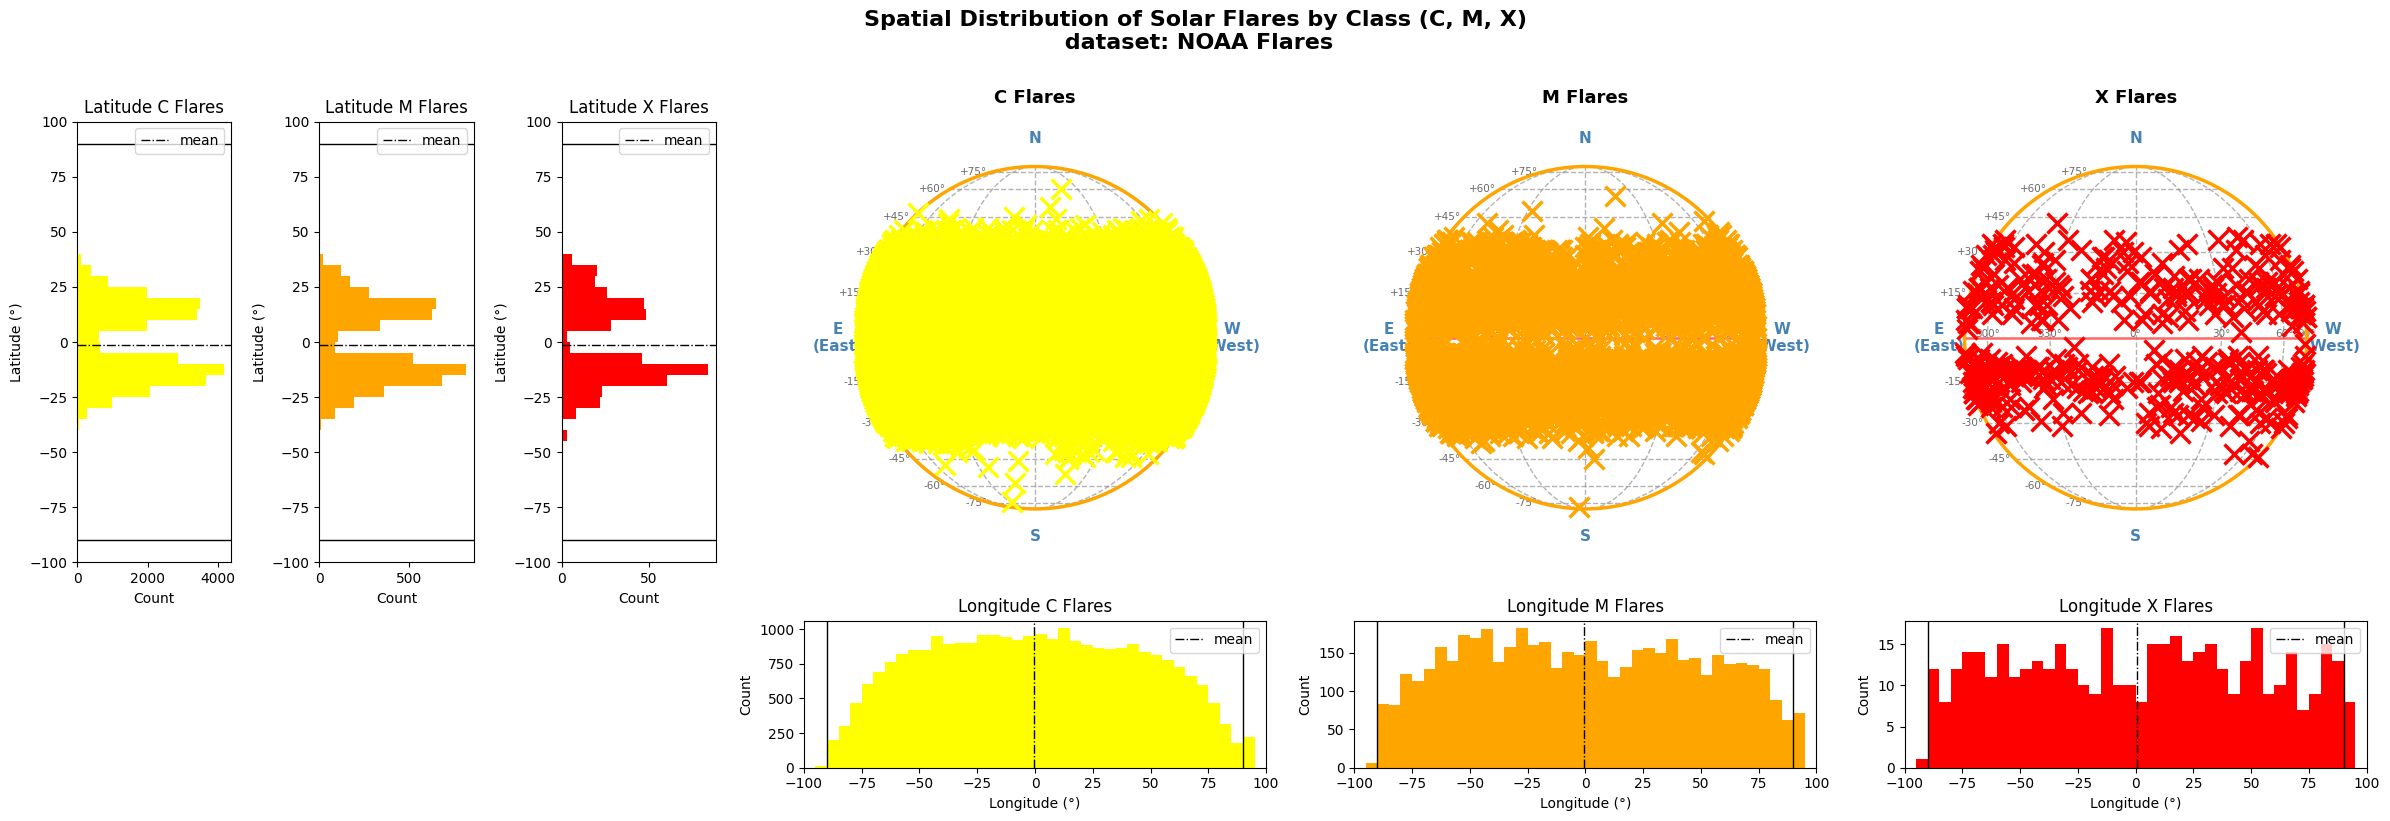

In [39]:
from usefull_functions import solarcoor2xy, draw_sun_xy
noaa_flares = dataset_reading.noaa_flares.dropna(subset=['lat_hg', 'long_hg', 'xray_class'])

noaa_flares_X = noaa_flares[noaa_flares['xray_class'].str[0] == 'X']
noaa_flares_M = noaa_flares[noaa_flares['xray_class'].str[0] == 'M']
noaa_flares_C = noaa_flares[noaa_flares['xray_class'].str[0] == 'C']

x_C, y_C, _ = solarcoor2xy(noaa_flares_C['lat_hg'], noaa_flares_C['long_hg'])
x_M, y_M, _ = solarcoor2xy(noaa_flares_M['lat_hg'], noaa_flares_M['long_hg'])
x_X, y_X, _ = solarcoor2xy(noaa_flares_X['lat_hg'], noaa_flares_X['long_hg'])

flares_data = [
    (noaa_flares_C, x_C, y_C, 'C Flares', 'yellow'),
    (noaa_flares_M, x_M, y_M, 'M Flares', 'orange'),
    (noaa_flares_X, x_X, y_X, 'X Flares', 'red'),
]

fig, axes = plt.subplots(2, 6, figsize=(24, 8), gridspec_kw={'width_ratios': [1, 1, 1, 3, 3, 3], 'height_ratios': [3, 1]})

fig.suptitle(
    "Spatial Distribution of Solar Flares by Class (C, M, X)\n dataset: NOAA Flares",
    fontsize=16,
    fontweight='bold',
    y=1.02        # ajuste la hauteur du titre (>1 = au-dessus des subplots)
)

for i, (df, x, y, title, color) in enumerate(flares_data):
    col_hist_lat = i * 2          
    
for i, (df, x, y, title, color) in enumerate(flares_data):
    
    ax_lat = axes[0, i]
    ax_lat.hist(df['lat_hg'], bins=np.arange(-100, 101, 5), orientation='horizontal', color=color)
    ax_lat.axhline(y=np.mean(df['lat_hg']),  color='black', linestyle='-.', linewidth=1, label = 'mean') 
    ax_lat.set_ylim(-100, 100)
    ax_lat.axhline(y=90,  color='black', linestyle='-', linewidth=1) 
    ax_lat.axhline(y=-90,  color='black', linestyle='-', linewidth=1) 
    ax_lat.set_title(f'Latitude {title}')
    ax_lat.set_ylabel('Latitude (°)')
    ax_lat.set_xlabel('Count')
    ax_lat.legend()

    
    ax_sun = axes[0, i + 3]
    draw_sun_xy(x, y, title=title, color=color, ax=ax_sun)

    
    ax_long = axes[1, i + 3]
    ax_long.hist(df['long_hg'], bins=np.arange(-100, 101, 5), orientation='vertical', color=color)
    ax_long.axvline(x=np.mean(df['long_hg']),  color='black', linestyle='-.', linewidth=1, label = 'mean')
    ax_long.set_xlim(-100, 100)
    ax_long.axvline(x=90,  color='black', linestyle='-', linewidth=1) 
    ax_long.axvline(x=-90,  color='black', linestyle='-', linewidth=1)  
    ax_long.set_title(f'Longitude {title}')
    ax_long.set_xlabel('Longitude (°)')
    ax_long.set_ylabel('Count')
    ax_long.legend()


for j in range(3):
    axes[1, j].axis('off')

plt.tight_layout()
plt.show()

In [40]:
laurenza = dataset_reading.laurenza.dropna(subset = ['Location', 'SXR Class']) 

laurenza_xflares = laurenza[laurenza['SXR Class'].str.startswith('X')]
laurenza_mflares = laurenza[laurenza['SXR Class'].str.startswith('M')]
laurenza_cflares = laurenza[laurenza['SXR Class'].str.startswith('C')]

laurenza_aug = format_lat_long_coordinates(laurenza, col='Location')
lat = laurenza_aug['lat']; long = laurenza_aug['long']


laurenza_aug_x = format_lat_long_coordinates(laurenza_xflares, col='Location')
lat_x = laurenza_aug_x['lat']; long_x = laurenza_aug_x['long']

laurenza_aug_m = format_lat_long_coordinates(laurenza_mflares, col='Location')
lat_m = laurenza_aug_m['lat']; long_m = laurenza_aug_m['long']

laurenza_aug_c = format_lat_long_coordinates(laurenza_cflares, col='Location')
lat_c = laurenza_aug_c['lat']; long_c = laurenza_aug_c['long']


x_c, y_c, _ = solarcoor2xy(lat_c, long_c)
x_m, y_m, _ = solarcoor2xy(lat_m, long_m)
x_x, y_x, _ = solarcoor2xy(lat_x, long_x)


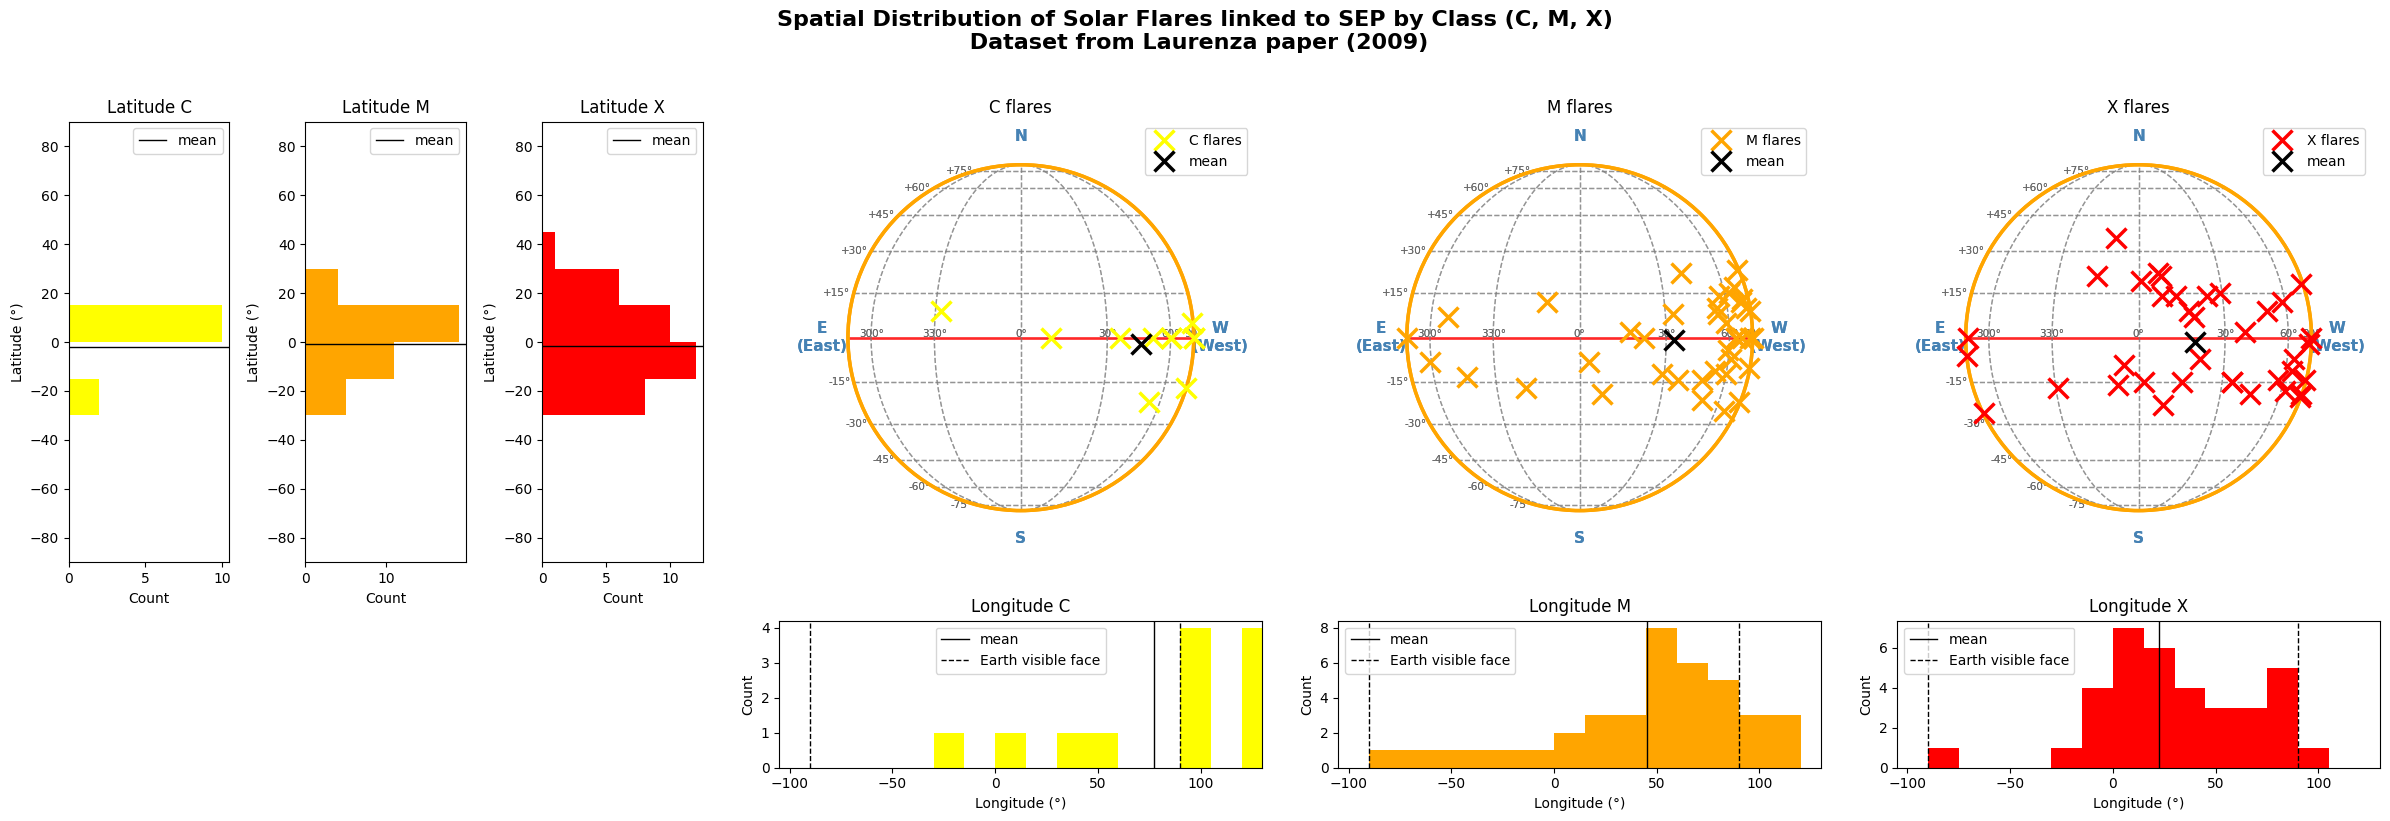

In [41]:
flares_data = [
    (laurenza_aug_c['lat'], laurenza_aug_c['long'], x_c, y_c, 'C', 'yellow', 'C flares'),
    (laurenza_aug_m['lat'], laurenza_aug_m['long'], x_m, y_m, 'M', 'orange', 'M flares'),
    (laurenza_aug_x['lat'], laurenza_aug_x['long'], x_x, y_x, 'X', 'red',    'X flares'),
]

fig, axes = plt.subplots(
    2, 6, figsize=(24, 8),
    gridspec_kw={'width_ratios': [1, 1, 1, 3, 3, 3], 'height_ratios': [3, 1]}
)

fig.suptitle(
    "Spatial Distribution of Solar Flares linked to SEP by Class (C, M, X)\n Dataset from Laurenza paper (2009)",
    fontsize=16, fontweight='bold', y=1.02
)


for i, (lat, long, x, y, title, color, label) in enumerate(flares_data):
    ax_lat = axes[0, i]
    ax_lat.hist(lat, bins=np.arange(-90, 91, 15), orientation='horizontal', color=color)
    ax_lat.axhline(y=np.mean(lat),  color='black', linestyle='-', linewidth=1, label = 'mean') 
    ax_lat.set_ylim(-90, 90)
    ax_lat.set_title(f'Latitude {title}')
    ax_lat.set_ylabel('Latitude (°)')
    ax_lat.set_xlabel('Count')
    ax_lat.legend()

    ax_sun = axes[0, i + 3]
    draw_sun_xy(x, y, color=color, ax=ax_sun, label=label)
    draw_sun_xy([np.mean(x)], [np.mean(y)], color='black', ax=ax_sun, label='mean')
    ax_sun.set_title(f'{title} flares')
    ax_sun.legend(loc='upper right')

    ax_long = axes[1, i + 3]
    ax_long.hist(long, bins=np.arange(-90, 136, 15), orientation='vertical', color=color)
    ax_long.axvline(x=np.mean(long),  color='black', linestyle='-', linewidth=1, label = 'mean') 
    ax_long.axvline(x=90,  color='black', linestyle='--', linewidth=1, label = 'Earth visible face') 
    ax_long.axvline(x=-90,  color='black', linestyle='--', linewidth=1)  
    ax_long.set_xlim(-105, 130)
    ax_long.set_title(f'Longitude {title}')
    ax_long.set_xlabel('Longitude (°)')
    ax_long.set_ylabel('Count')
    ax_long.legend()

for j in range(3):
    axes[1, j].axis('off')

plt.tight_layout()
plt.show()

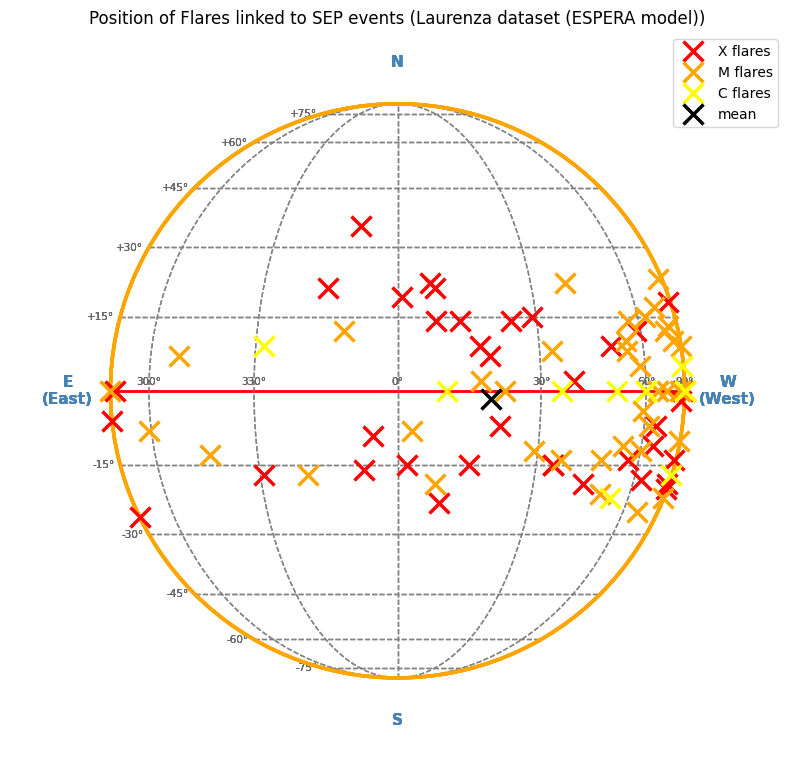

In [42]:
fig, ax = plt.subplots(figsize=(10, 10))

x_x,y_x,_ = solarcoor2xy(lat_x, long_x)
draw_sun_xy(x_x,y_x, color = 'red', ax=ax, label = 'X flares')

x_m,y_m,_ = solarcoor2xy(lat_m, long_m)
draw_sun_xy(x_m,y_m, color = 'orange', ax=ax, label = 'M flares')

x_c,y_c,_ = solarcoor2xy(lat_c, long_c)
draw_sun_xy(x_c,y_c, color = 'yellow', ax=ax, label = 'C flares')

x,y,_ = solarcoor2xy(lat, long)
draw_sun_xy([np.mean(x)], [np.mean(y)], color='black', ax=ax, label='mean')

ax.legend(loc='upper right', fontsize=10)
plt.title('Position of Flares linked to SEP events (Laurenza dataset (ESPERA model))')
plt.show()


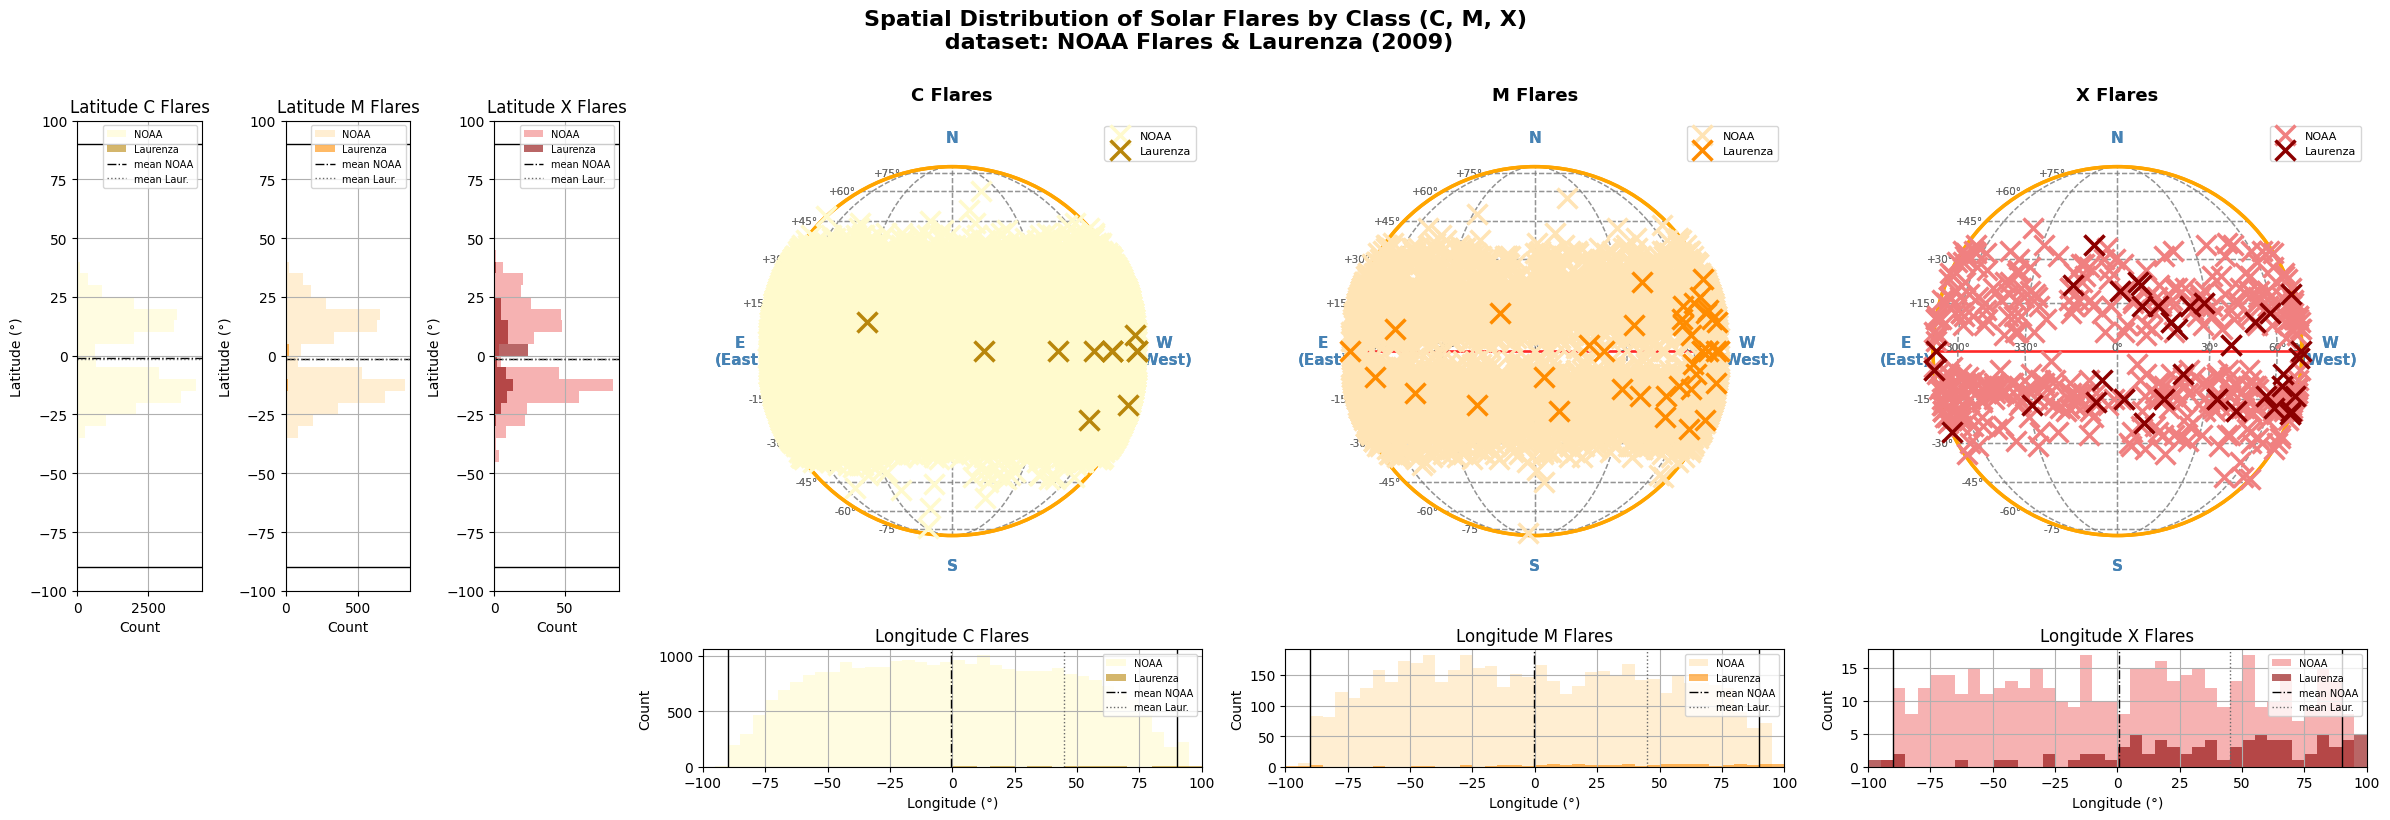

In [43]:
flares_grouped = [
    # (df_noaa, x_noaa, y_noaa, df_laur, x_laur, y_laur, title, color_noaa, color_laur)
    (noaa_flares_C, x_C, y_C, laurenza_cflares, x_c, y_c, 'C Flares', 'lemonchiffon',   'darkgoldenrod'),
    (noaa_flares_M, x_M, y_M, laurenza_mflares, x_m, y_m, 'M Flares', 'moccasin', 'darkorange'),
    (noaa_flares_X, x_X, y_X, laurenza_xflares, x_x, y_x, 'X Flares', 'lightcoral',    'darkred'),
]


fig, axes = plt.subplots(2, 6, figsize=(24, 8),
                         gridspec_kw={'width_ratios': [1, 1, 1, 4, 4,4],
                                      'height_ratios': [4, 1]})

fig.suptitle(
    "Spatial Distribution of Solar Flares by Class (C, M, X)\n dataset: NOAA Flares & Laurenza (2009)",
    fontsize=16, fontweight='bold', y=1.02
)

for i, (df_n, x_n, y_n, df_l, x_l, y_l, title, c_n, c_l) in enumerate(flares_grouped):

    # ---- Plot du Soleil (colonnes 3,4,5) ----
    ax_sun = axes[0, i + 3]
    draw_sun_xy(x_n, y_n, title=title, color=c_n, ax=ax_sun, label='NOAA')
    draw_sun_xy(x_l, y_l, title=title, color=c_l, ax=ax_sun, label='Laurenza')
    ax_sun.legend(fontsize=8)

    # ---- Histogramme Latitude (colonnes 0,1,2) ----
    ax_lat = axes[0, i]
    bins_lat = np.arange(-100, 101, 5)
    ax_lat.hist(df_n['lat_hg'], bins=bins_lat, orientation='horizontal',
                color=c_n, alpha=0.6, label='NOAA')
    ax_lat.hist(laurenza_aug['lat'], bins=bins_lat, orientation='horizontal',
                color=c_l, alpha=0.6, label='Laurenza')
    ax_lat.axhline(y=np.mean(df_n['lat_hg']), color='black',     linestyle='-.', linewidth=1, label='mean NOAA')
    ax_lat.axhline(y=np.mean(laurenza_aug['lat']), color='dimgray',   linestyle=':',  linewidth=1, label='mean Laur.')
    ax_lat.set_ylim(-100, 100)
    ax_lat.axhline(y=90,  color='black', linestyle='-', linewidth=1)
    ax_lat.axhline(y=-90, color='black', linestyle='-', linewidth=1)
    ax_lat.set_title(f'Latitude {title}')
    ax_lat.set_ylabel('Latitude (°)')
    ax_lat.set_xlabel('Count')
    ax_lat.legend(fontsize=7)
    ax_lat.grid()

    # ---- Histogramme Longitude (colonnes 3,4,5 ligne du bas) ----
    ax_long = axes[1, i + 3]
    bins_long = np.arange(-100, 101, 5)
    ax_long.hist(df_n['long_hg'], bins=bins_long, orientation='vertical',
                 color=c_n, alpha=0.6, label='NOAA')
    ax_long.hist(laurenza_aug['long'], bins=bins_long, orientation='vertical',
                 color=c_l, alpha=0.6, label='Laurenza')
    ax_long.axvline(x=np.mean(df_n['long_hg']), color='black',   linestyle='-.', linewidth=1, label='mean NOAA')
    ax_long.axvline(x=np.mean(laurenza_aug['long']), color='dimgray', linestyle=':',  linewidth=1, label='mean Laur.')
    ax_long.set_xlim(-100, 100)
    ax_long.axvline(x=90,  color='black', linestyle='-', linewidth=1)
    ax_long.axvline(x=-90, color='black', linestyle='-', linewidth=1)
    ax_long.set_title(f'Longitude {title}')
    ax_long.set_xlabel('Longitude (°)')
    ax_long.set_ylabel('Count')
    ax_long.legend(fontsize=7)
    ax_long.grid()

# Désactiver les axes vides du bas-gauche
for j in range(3):
    axes[1, j].axis('off')

plt.tight_layout()
plt.show()

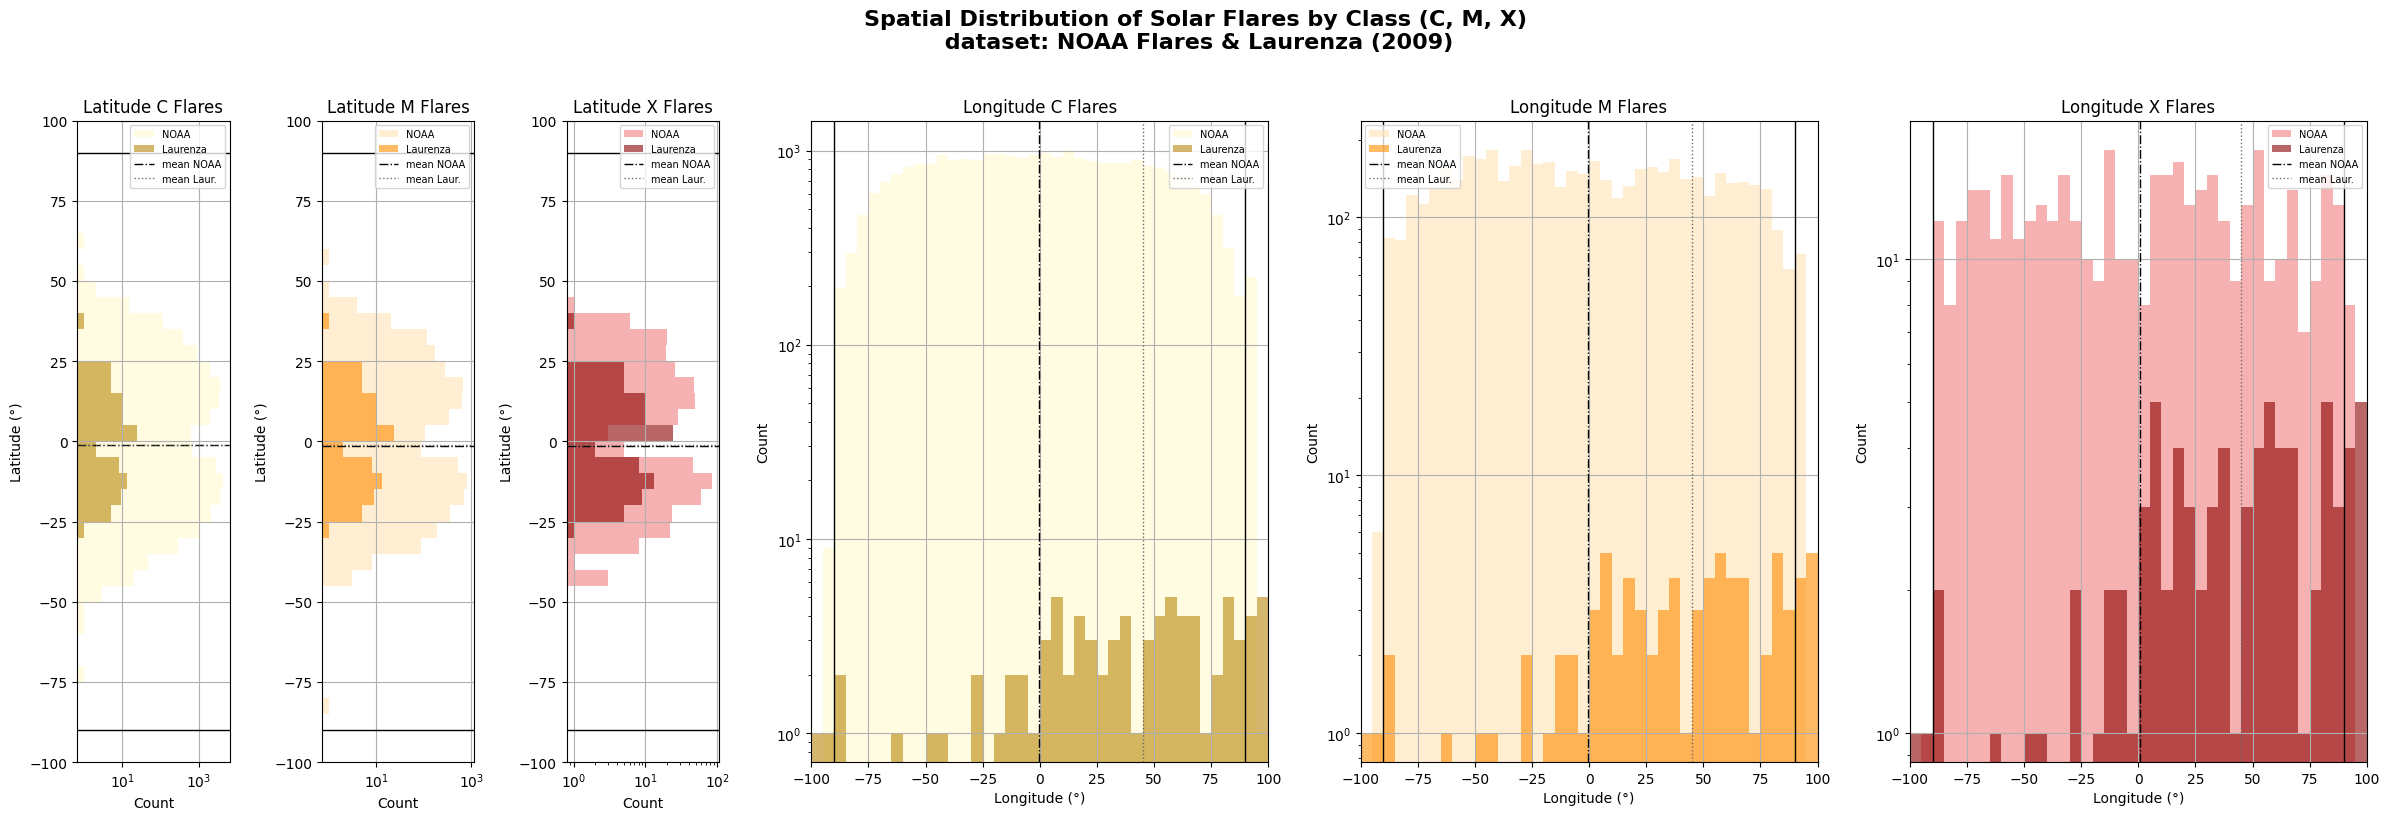

In [44]:
fig, axes = plt.subplots(1, 6, figsize=(24, 8),
                         gridspec_kw={'width_ratios': [1, 1, 1, 3,3,3]})

fig.suptitle(
    "Spatial Distribution of Solar Flares by Class (C, M, X)\n dataset: NOAA Flares & Laurenza (2009)",
    fontsize=16, fontweight='bold', y=1.02
)

for i, (df_n, x_n, y_n, df_l, x_l, y_l, title, c_n, c_l) in enumerate(flares_grouped):

    # ---- Histogramme LOG Latitude (colonnes 0,1,2) ----
    ax_lat = axes[i]
    bins_lat = np.arange(-100, 101, 5)
    ax_lat.hist(df_n['lat_hg'], bins=bins_lat, orientation='horizontal',
                color=c_n, alpha=0.6, label='NOAA')
    ax_lat.hist(laurenza_aug['lat'], bins=bins_lat, orientation='horizontal',
                color=c_l, alpha=0.6, label='Laurenza')
    ax_lat.axhline(y=np.mean(df_n['lat_hg']), color='black',     linestyle='-.', linewidth=1, label='mean NOAA')
    ax_lat.axhline(y=np.mean(laurenza_aug['lat']), color='dimgray',   linestyle=':',  linewidth=1, label='mean Laur.')
    ax_lat.set_xscale('log')
    ax_lat.set_ylim(-100, 100)
    ax_lat.axhline(y=90,  color='black', linestyle='-', linewidth=1)
    ax_lat.axhline(y=-90, color='black', linestyle='-', linewidth=1)
    ax_lat.set_title(f'Latitude {title}')
    ax_lat.set_ylabel('Latitude (°)')
    ax_lat.set_xlabel('Count')
    ax_lat.legend(fontsize=7)
    ax_lat.grid()

    # ---- Histogramme LOG Longitude (colonnes 3,4,5) ----
    ax_long = axes[i + 3]
    bins_long = np.arange(-100, 101, 5)
    ax_long.hist(df_n['long_hg'], bins=bins_long, orientation='vertical',
                 color=c_n, alpha=0.6, label='NOAA')
    ax_long.hist(laurenza_aug['long'], bins=bins_long, orientation='vertical',
                 color=c_l, alpha=0.6, label='Laurenza')
    ax_long.axvline(x=np.mean(df_n['long_hg']), color='black',   linestyle='-.', linewidth=1, label='mean NOAA')
    ax_long.axvline(x=np.mean(laurenza_aug['long']), color='dimgray', linestyle=':',  linewidth=1, label='mean Laur.')
    ax_long.set_yscale('log')
    ax_long.set_xlim(-100, 100)
    ax_long.axvline(x=90,  color='black', linestyle='-', linewidth=1)
    ax_long.axvline(x=-90, color='black', linestyle='-', linewidth=1)
    ax_long.set_title(f'Longitude {title}')
    ax_long.set_xlabel('Longitude (°)')
    ax_long.set_ylabel('Count')
    ax_long.legend(fontsize=7)
    ax_long.grid()

plt.tight_layout()
plt.show()

c:\Users\pierr\OneDrive - IPSA\Documents\IPSA\Aero 4\Stage A4\BIRA IASB Bruxelles\code\git-internship\usefull_functions.py:405: RuntimeWarning: invalid value encountered in divide
  probability_matrix = (lat_long_sep/lat_long_flares)*100


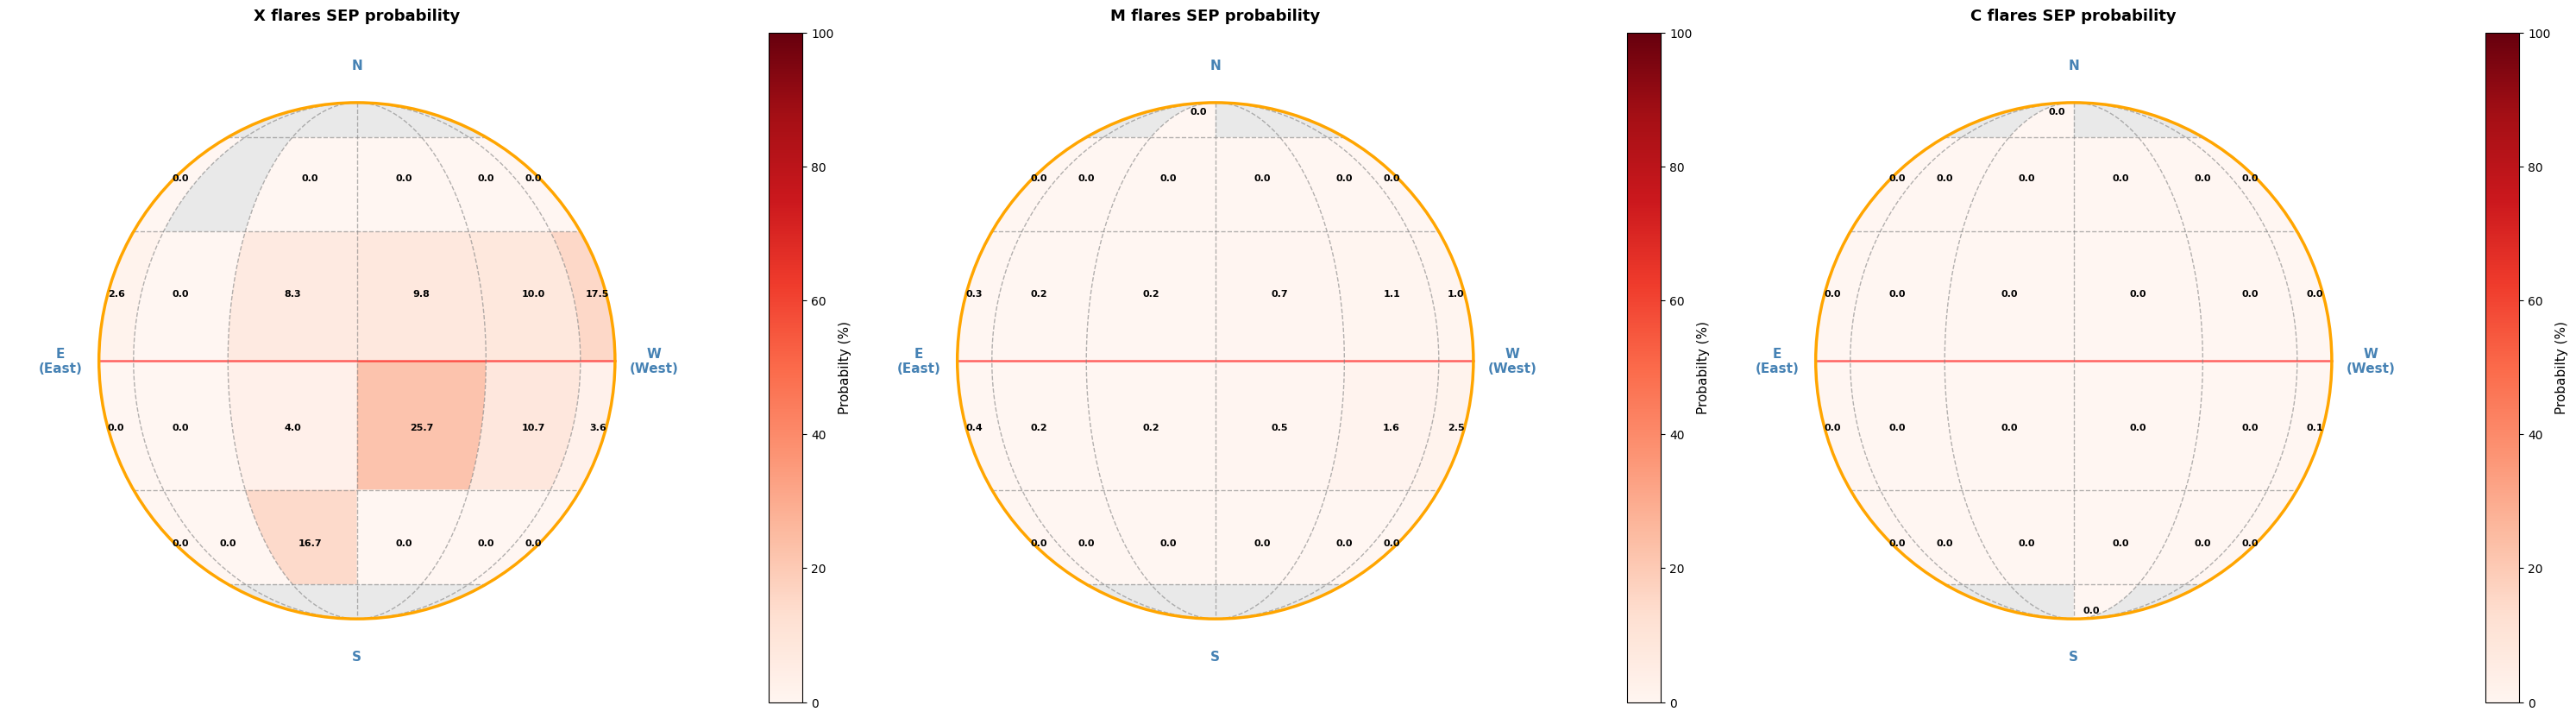

In [45]:
noaa_flares = dataset_reading.noaa_flares.dropna(subset=['lat_hg', 'long_hg', 'xray_class'])
laurenza = dataset_reading.laurenza.dropna(subset = ['Location', 'SXR Class']) 


#-------------------------------X flares-----------------------------------------------------------

laurenza_xflares = laurenza[laurenza['SXR Class'].str.startswith('X')]
laurenza_aug_x = format_lat_long_coordinates(laurenza_xflares, col='Location')
lat_sep_x = laurenza_aug_x['lat']; long_sep_x = laurenza_aug_x['long']

noaa_flares_X = noaa_flares[noaa_flares['xray_class'].str.startswith('X')]
lat_flares_x = noaa_flares_X['lat_hg']; long_flares_x = noaa_flares_X['long_hg']



#-------------------------------M flares-----------------------------------------------------------

laurenza_mflares = laurenza[laurenza['SXR Class'].str.startswith('M')]
laurenza_aug_m = format_lat_long_coordinates(laurenza_mflares, col='Location')
lat_sep_m = laurenza_aug_m['lat']; long_sep_m = laurenza_aug_m['long']

noaa_flares_m = noaa_flares[noaa_flares['xray_class'].str.startswith('M')]
lat_flares_m = noaa_flares_m['lat_hg']; long_flares_m = noaa_flares_m['long_hg']



#-------------------------------C flares-----------------------------------------------------------

laurenza_cflares = laurenza[laurenza['SXR Class'].str.startswith('C')]
laurenza_aug_c = format_lat_long_coordinates(laurenza_cflares, col='Location')
lat_sep_c = laurenza_aug_c['lat']; long_sep_c = laurenza_aug_c['long']

noaa_flares_c = noaa_flares[noaa_flares['xray_class'].str.startswith('C')]
lat_flares_c = noaa_flares_c['lat_hg']; long_flares_c = noaa_flares_c['long_hg']

#-------------------------------plot-----------------------------------------------------------


fig, axes = plt.subplots(1, 3, figsize=(30, 10))

plot_sep_over_flare_probability(lat_sep_x, long_sep_x, lat_flares_x, long_flares_x, 
                                title='X flares SEP probability', ax=axes[0])
plot_sep_over_flare_probability(lat_sep_m, long_sep_m, lat_flares_m, long_flares_m, 
                                title='M flares SEP probability', ax=axes[1])
plot_sep_over_flare_probability(lat_sep_c, long_sep_c, lat_flares_c, long_flares_c, 
                                title='C flares SEP probability', ax=axes[2])

plt.tight_layout()
plt.show()


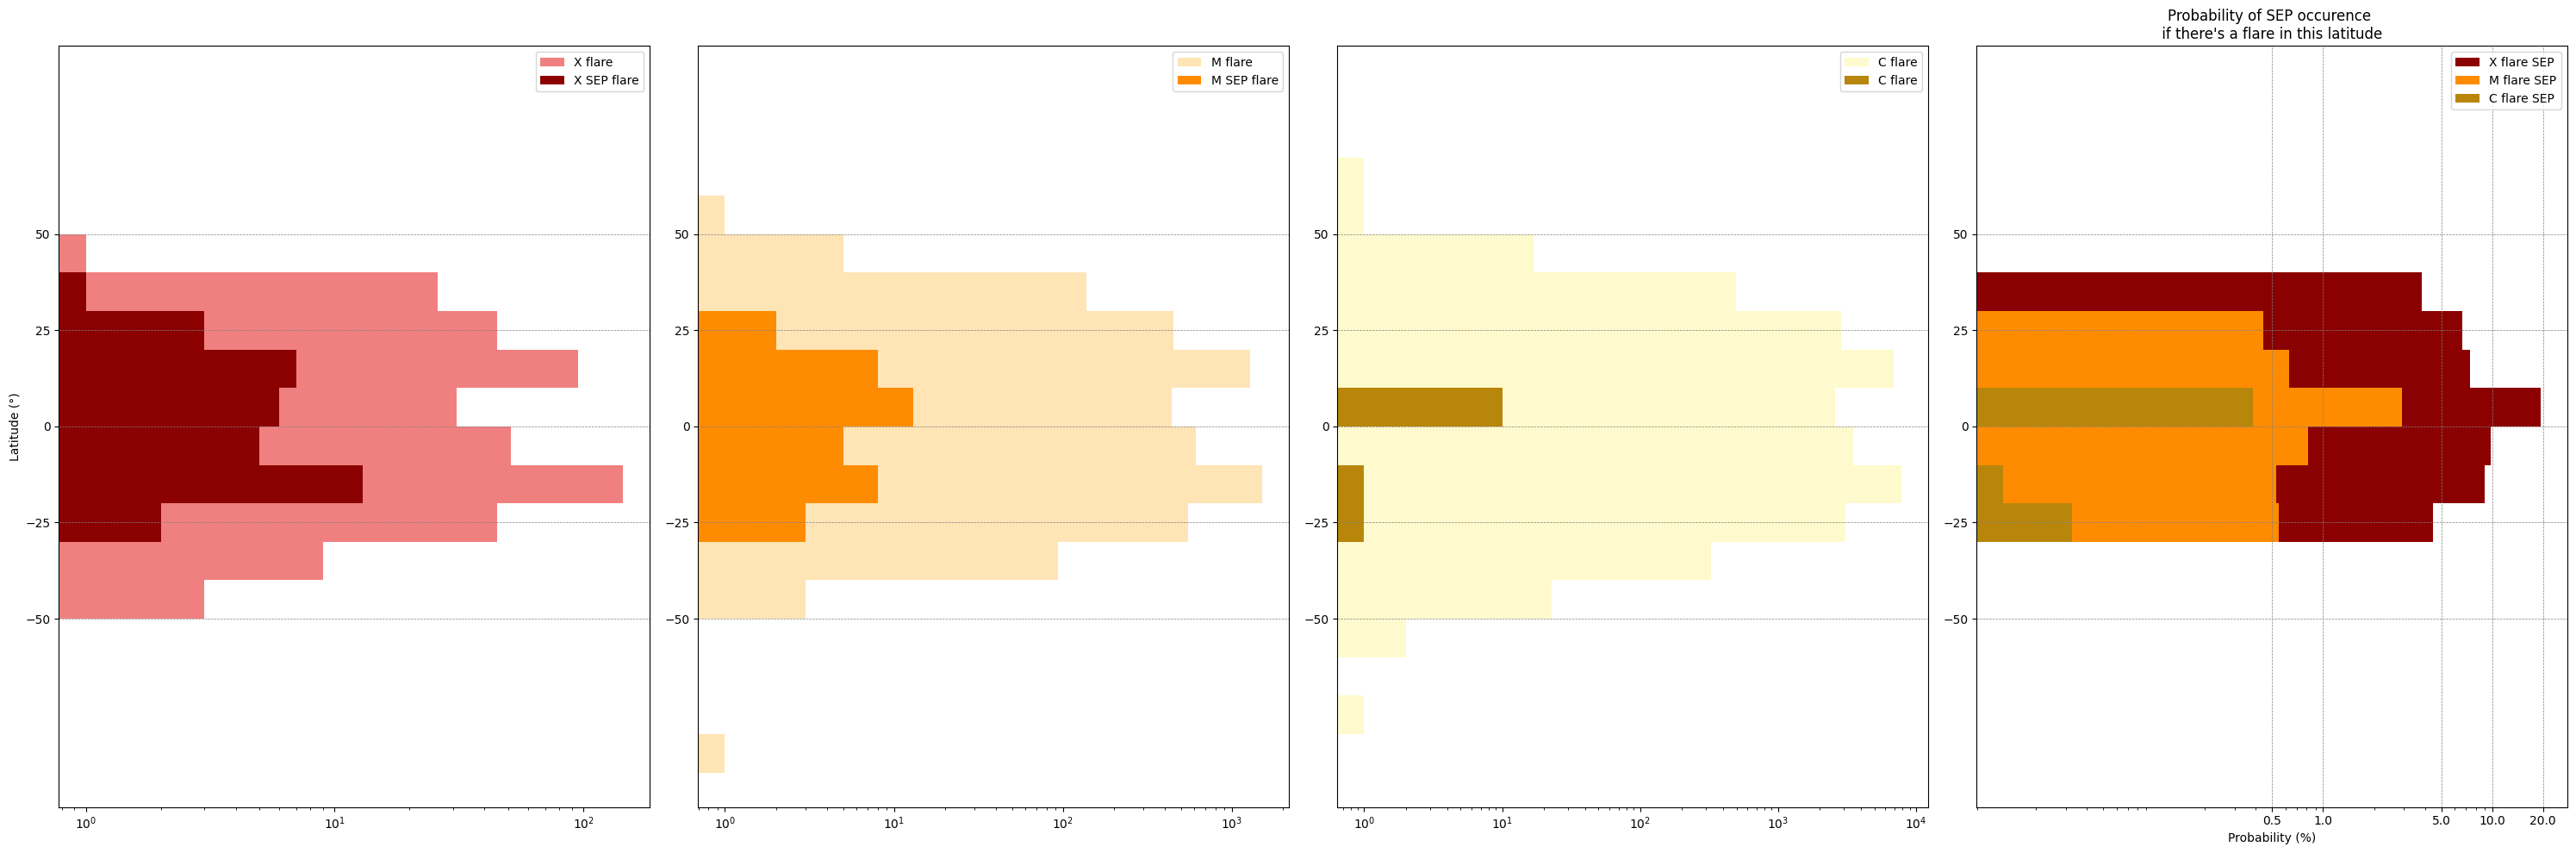

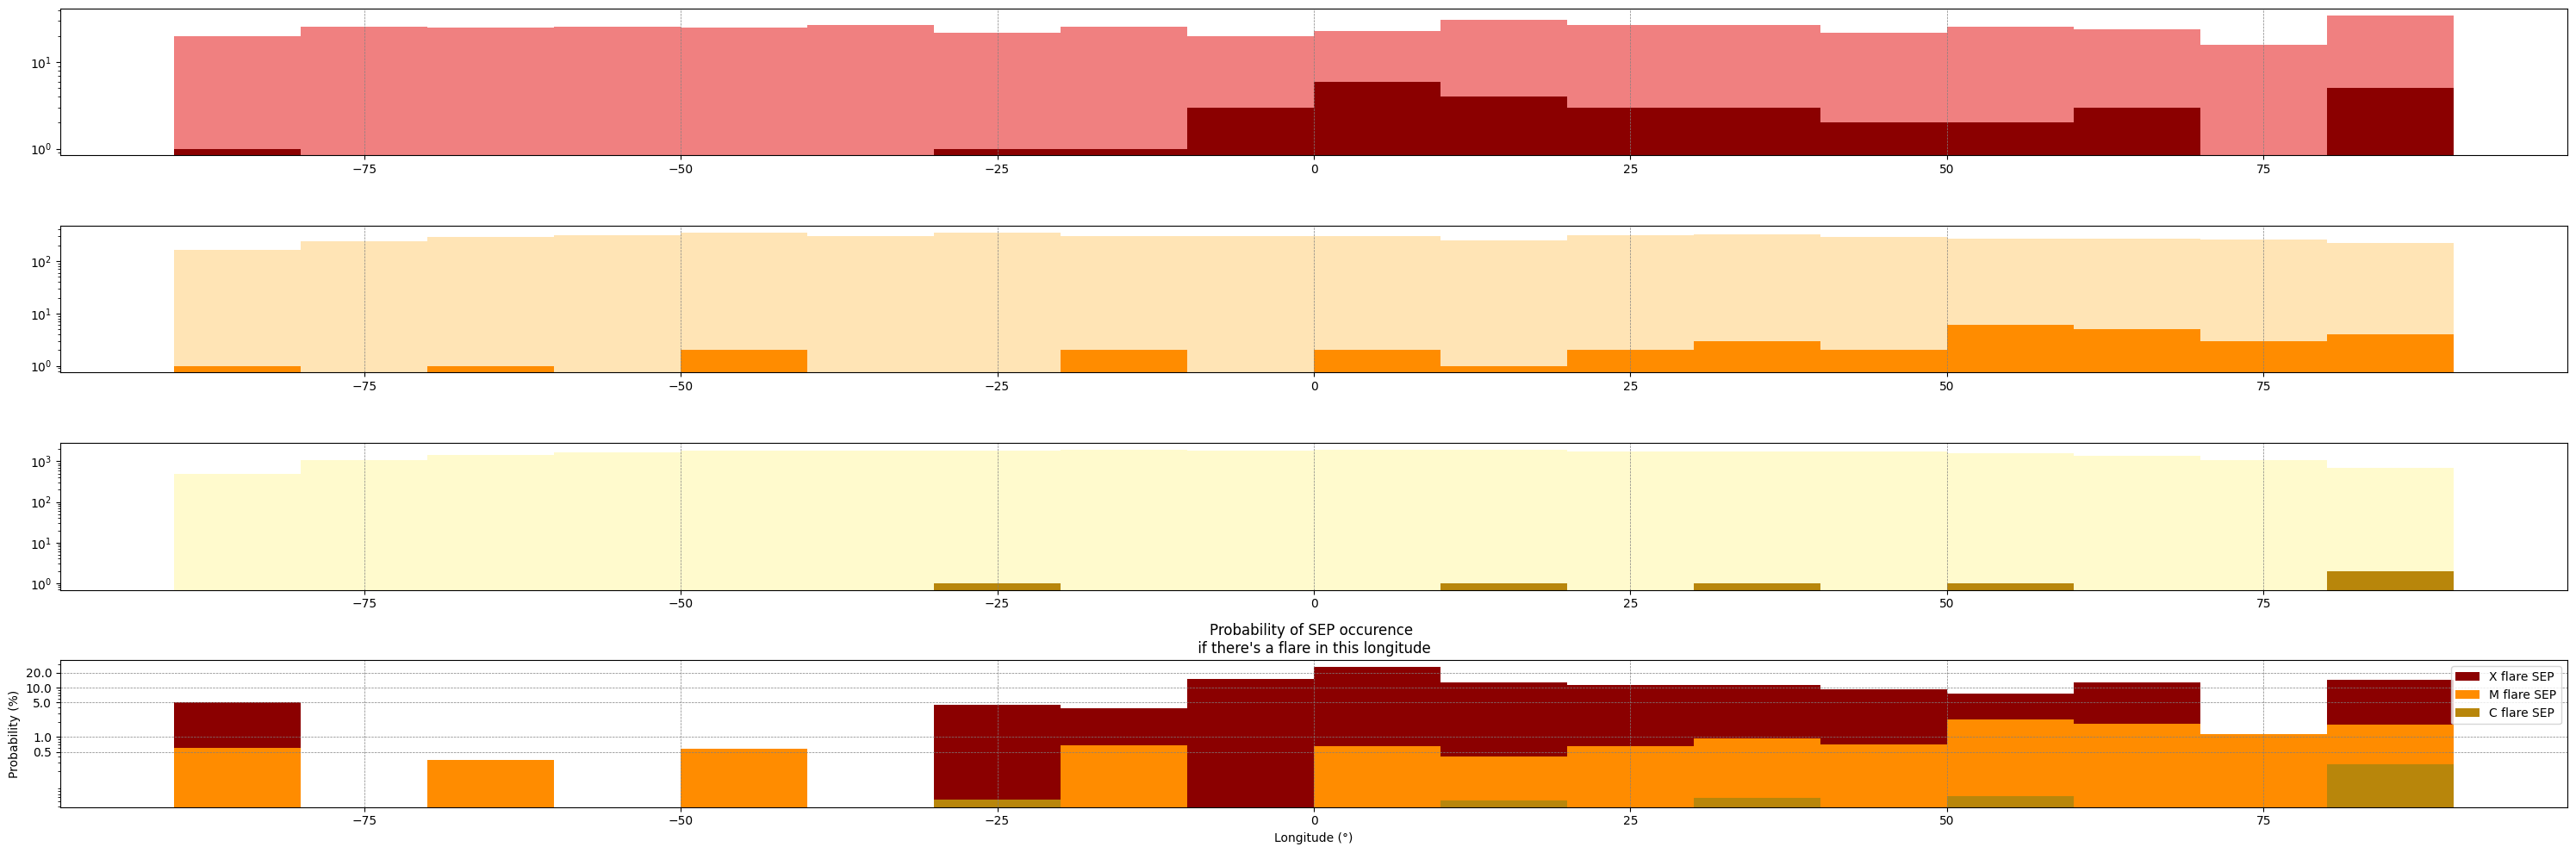

In [46]:


fig, ax = plt.subplots(1, 4, figsize=(30, 10))
n_lat_flares_x, _, _ = ax[0].hist(lat_flares_x, bins = np.arange(-90,91,10), color = 'lightcoral', orientation = 'horizontal', label = 'X flare')
n_sep_x, _, _ = ax[0].hist(lat_sep_x, bins = np.arange(-90,91,10), color = 'darkred', orientation = 'horizontal', label = 'X SEP flare')
ax[0].set_xscale('log')
ax[0].set_ylabel('Latitude (°)')
ax[0].legend()
ax[0].set_yticks([-50, -25, 0, 25, 50])
ax[0].get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax[0].grid(axis='y', which='major', linestyle='--', linewidth=0.5, color='gray')



n_lat_flares_m, _, _ =ax[1].hist(lat_flares_m, bins = np.arange(-90,91,10), color = 'moccasin', orientation = 'horizontal', label ='M flare')
n_sep_m, _, _ =ax[1].hist(lat_sep_m, bins = np.arange(-90,91,10), color = 'darkorange', orientation = 'horizontal', label = 'M SEP flare')
ax[1].set_xscale('log')
ax[1].legend()
ax[1].set_yticks([-50, -25, 0, 25, 50])
ax[1].get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax[1].grid(axis='y', which='major', linestyle='--', linewidth=0.5, color='gray')



n_lat_flares_c, _, _ =ax[2].hist(lat_flares_c, bins = np.arange(-90,91,10), color = 'lemonchiffon', orientation = 'horizontal', label = 'C flare')
n_sep_c, _, _ =ax[2].hist(lat_sep_c, bins = np.arange(-90,91,10), color = 'darkgoldenrod', orientation = 'horizontal', label = 'C flare')
ax[2].set_xscale('log')
ax[2].legend()
ax[2].set_yticks([-50, -25, 0, 25, 50])
ax[2].get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax[2].grid(axis='y', which='major', linestyle='--', linewidth=0.5, color='gray')





with np.errstate(divide='ignore', invalid='ignore'):  # Ignore les warnings de division par zéro
    ratio_lat_x = np.divide(n_sep_x, n_lat_flares_x) 
    ratio_lat_m = np.divide(n_sep_m, n_lat_flares_m)
    ratio_lat_c = np.divide(n_sep_c, n_lat_flares_c)
    
       
ratio_lat_x = np.nan_to_num(ratio_lat_x, nan=0.0, posinf=0.0, neginf=0.0)
ratio_lat_x *=100 #to have %
ratio_lat_x = np.round(ratio_lat_x, decimals=4)

ratio_lat_m = np.nan_to_num(ratio_lat_m, nan=0.0, posinf=0.0, neginf=0.0)
ratio_lat_m *=100 #to have %
ratio_lat_m = np.round(ratio_lat_m, decimals=4)

ratio_lat_c = np.nan_to_num(ratio_lat_c, nan=0.0, posinf=0.0, neginf=0.0)
ratio_lat_c *=100 #to have %
ratio_lat_c = np.round(ratio_lat_c, decimals=4)

ax[3].barh(y=np.arange(-85, 86, 10),width=ratio_lat_x, height=10, color='darkred', alpha=1, label = 'X flare SEP')
ax[3].barh(y=np.arange(-85, 86, 10),width=ratio_lat_m, height=10, color='darkorange', alpha=1, label = 'M flare SEP')
ax[3].barh(y=np.arange(-85, 86, 10),width=ratio_lat_c, height=10, color='darkgoldenrod', alpha=1, label = 'C flare SEP')
ax[3].set_xscale('log')
ax[3].set_title('Probability of SEP occurence \n if there\'s a flare in this latitude ')
ax[3].set_xlabel('Probability (%)')
ax[3].legend()

ax[3].set_xticks([0.5,1, 5, 10, 20])
ax[3].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax[3].grid(axis='x', which='major', linestyle='--', linewidth=0.5, color='gray')

ax[3].set_yticks([-50, -25, 0, 25, 50])
ax[3].get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax[3].grid(axis='y', which='major', linestyle='--', linewidth=0.5, color='gray')



plt.tight_layout()
plt.show()

#%%-------------------------------plot LONG-----------------------------------------------------------


fig, ax = plt.subplots(4, 1, figsize=(30, 10))
np_long_flares_x, _, _ = ax[0].hist(long_flares_x, bins = np.arange(-90,91,10), color = 'lightcoral')
n_sep_x, _, _ = ax[0].hist(long_sep_x, bins = np.arange(-90,91,10), color = 'darkred')
ax[0].set_yscale('log')
ax[0].set_xticks([-75,-50, -25, 0, 25, 50, 75])
ax[0].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax[0].grid(axis='x', which='major', linestyle='--', linewidth=0.5, color='gray')


np_long_flares_m, _, _ =ax[1].hist(long_flares_m, bins = np.arange(-90,91,10), color = 'moccasin')
n_sep_m, _, _ =ax[1].hist(long_sep_m, bins = np.arange(-90,91,10), color = 'darkorange')
ax[1].set_yscale('log')
ax[1].set_xticks([-75,-50, -25, 0, 25, 50, 75])
ax[1].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax[1].grid(axis='x', which='major', linestyle='--', linewidth=0.5, color='gray')



np_long_flares_c, _, _ =ax[2].hist(long_flares_c, bins = np.arange(-90,91,10), color = 'lemonchiffon')
n_sep_c, _, _ =ax[2].hist(long_sep_c, bins = np.arange(-90,91,10), color = 'darkgoldenrod')
ax[2].set_yscale('log')
ax[2].set_xticks([-75,-50, -25, 0, 25, 50, 75])
ax[2].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax[2].grid(axis='x', which='major', linestyle='--', linewidth=0.5, color='gray')





with np.errstate(divide='ignore', invalid='ignore'):  # Ignore les warnings de division par zéro
    ratio_long_x = np.divide(n_sep_x, np_long_flares_x) 
    ratio_long_m = np.divide(n_sep_m, np_long_flares_m)
    ratio_long_c = np.divide(n_sep_c, np_long_flares_c)
    
       
ratio_long_x = np.nan_to_num(ratio_long_x, nan=0.0, posinf=0.0, neginf=0.0)
ratio_long_x *=100 #to have %
ratio_long_x = np.round(ratio_long_x, decimals=4)

ratio_long_m = np.nan_to_num(ratio_long_m, nan=0.0, posinf=0.0, neginf=0.0)
ratio_long_m *=100 #to have %
ratio_long_m = np.round(ratio_long_m, decimals=4)

ratio_long_c = np.nan_to_num(ratio_long_c, nan=0.0, posinf=0.0, neginf=0.0)
ratio_long_c *=100 #to have %
ratio_long_c = np.round(ratio_long_c, decimals=4)



ax[3].bar(x=np.arange(-85, 86, 10),height=ratio_long_x, width=10, color='darkred', alpha=1, label = 'X flare SEP')
ax[3].bar(x=np.arange(-85, 86, 10),height=ratio_long_m, width=10, color='darkorange', alpha=1, label = 'M flare SEP')
ax[3].bar(x=np.arange(-85, 86, 10),height=ratio_long_c, width=10, color='darkgoldenrod', alpha=1, label = 'C flare SEP')
ax[3].set_yscale('log')
ax[3].set_title('Probability of SEP occurence \n if there\'s a flare in this longitude ')
ax[3].set_ylabel('Probability (%)')
ax[3].set_xlabel('Longitude (°)')
ax[3].legend()


ax[3].set_yticks([0.5,1, 5, 10, 20])
ax[3].get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax[3].grid(axis='y', which='major', linestyle='--', linewidth=0.5, color='gray')

ax[3].set_xticks([-75,-50, -25, 0, 25, 50, 75])
ax[3].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax[3].grid(axis='x', which='major', linestyle='--', linewidth=0.5, color='gray')


plt.tight_layout()
plt.show()

In [47]:
print(ratio_lat_c)
print(ratio_lat_m)
print(ratio_lat_x)
print(ratio_long_c)
print(ratio_long_m)
print(ratio_long_x)

[0.     0.     0.     0.     0.     0.     0.0326 0.0128 0.     0.3854
 0.     0.     0.     0.     0.     0.     0.     0.    ]
[0.     0.     0.     0.     0.     0.     0.5455 0.5295 0.8157 2.9345
 0.6255 0.4425 0.     0.     0.     0.     0.     0.    ]
[ 0.      0.      0.      0.      0.      0.      4.4444  9.0278  9.8039
 19.3548  7.3684  6.6667  3.8462  0.      0.      0.      0.      0.    ]
[0.     0.     0.     0.     0.     0.     0.0539 0.     0.     0.
 0.052  0.     0.0581 0.     0.0628 0.     0.     0.2845]
[0.6061 0.     0.3484 0.     0.5698 0.     0.     0.678  0.     0.6536
 0.3984 0.6431 0.9434 0.7018 2.2305 1.8315 1.1407 1.81  ]
[ 5.      0.      0.      0.      0.      0.      4.5455  3.8462 15.
 26.087  12.9032 11.1111 11.1111  9.0909  7.6923 12.5     0.     14.2857]


## With GSEP

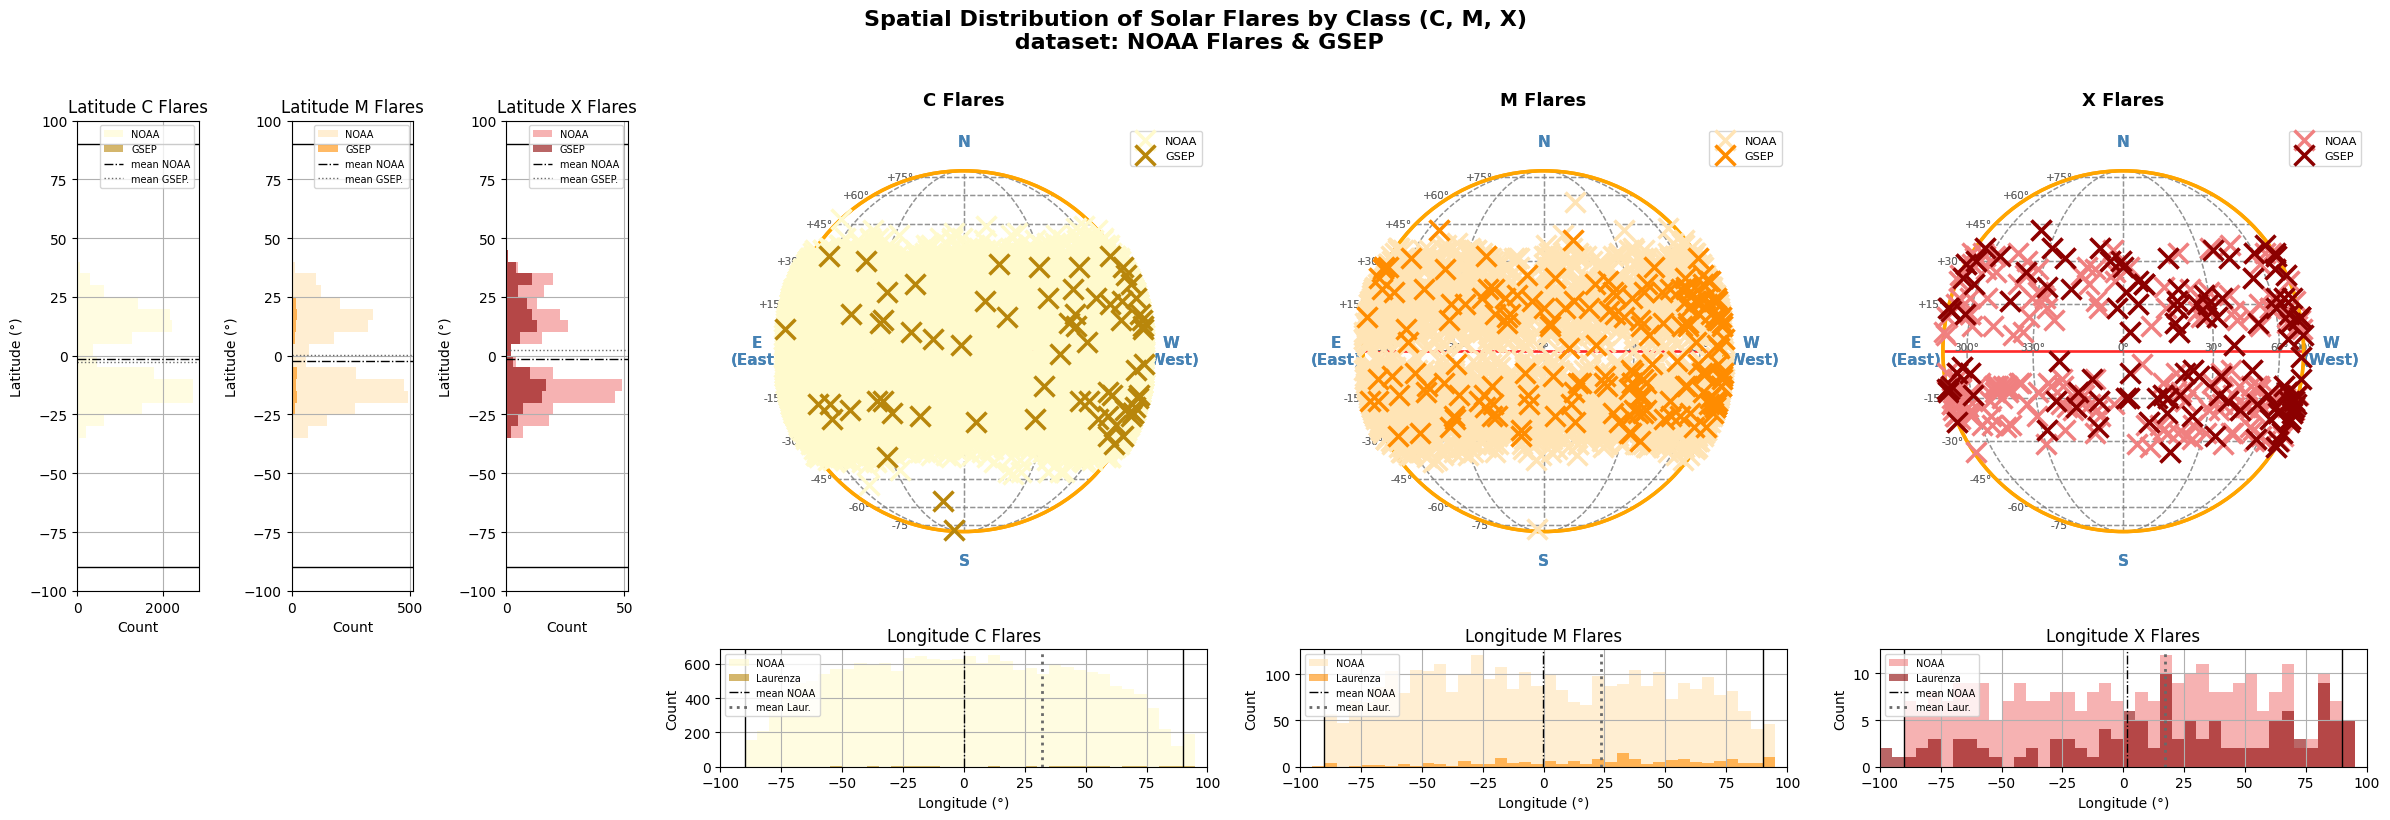

c:\Users\pierr\OneDrive - IPSA\Documents\IPSA\Aero 4\Stage A4\BIRA IASB Bruxelles\code\git-internship\usefull_functions.py:405: RuntimeWarning: invalid value encountered in divide
  probability_matrix = (lat_long_sep/lat_long_flares)*100
c:\Users\pierr\OneDrive - IPSA\Documents\IPSA\Aero 4\Stage A4\BIRA IASB Bruxelles\code\git-internship\usefull_functions.py:405: RuntimeWarning: divide by zero encountered in divide
  probability_matrix = (lat_long_sep/lat_long_flares)*100


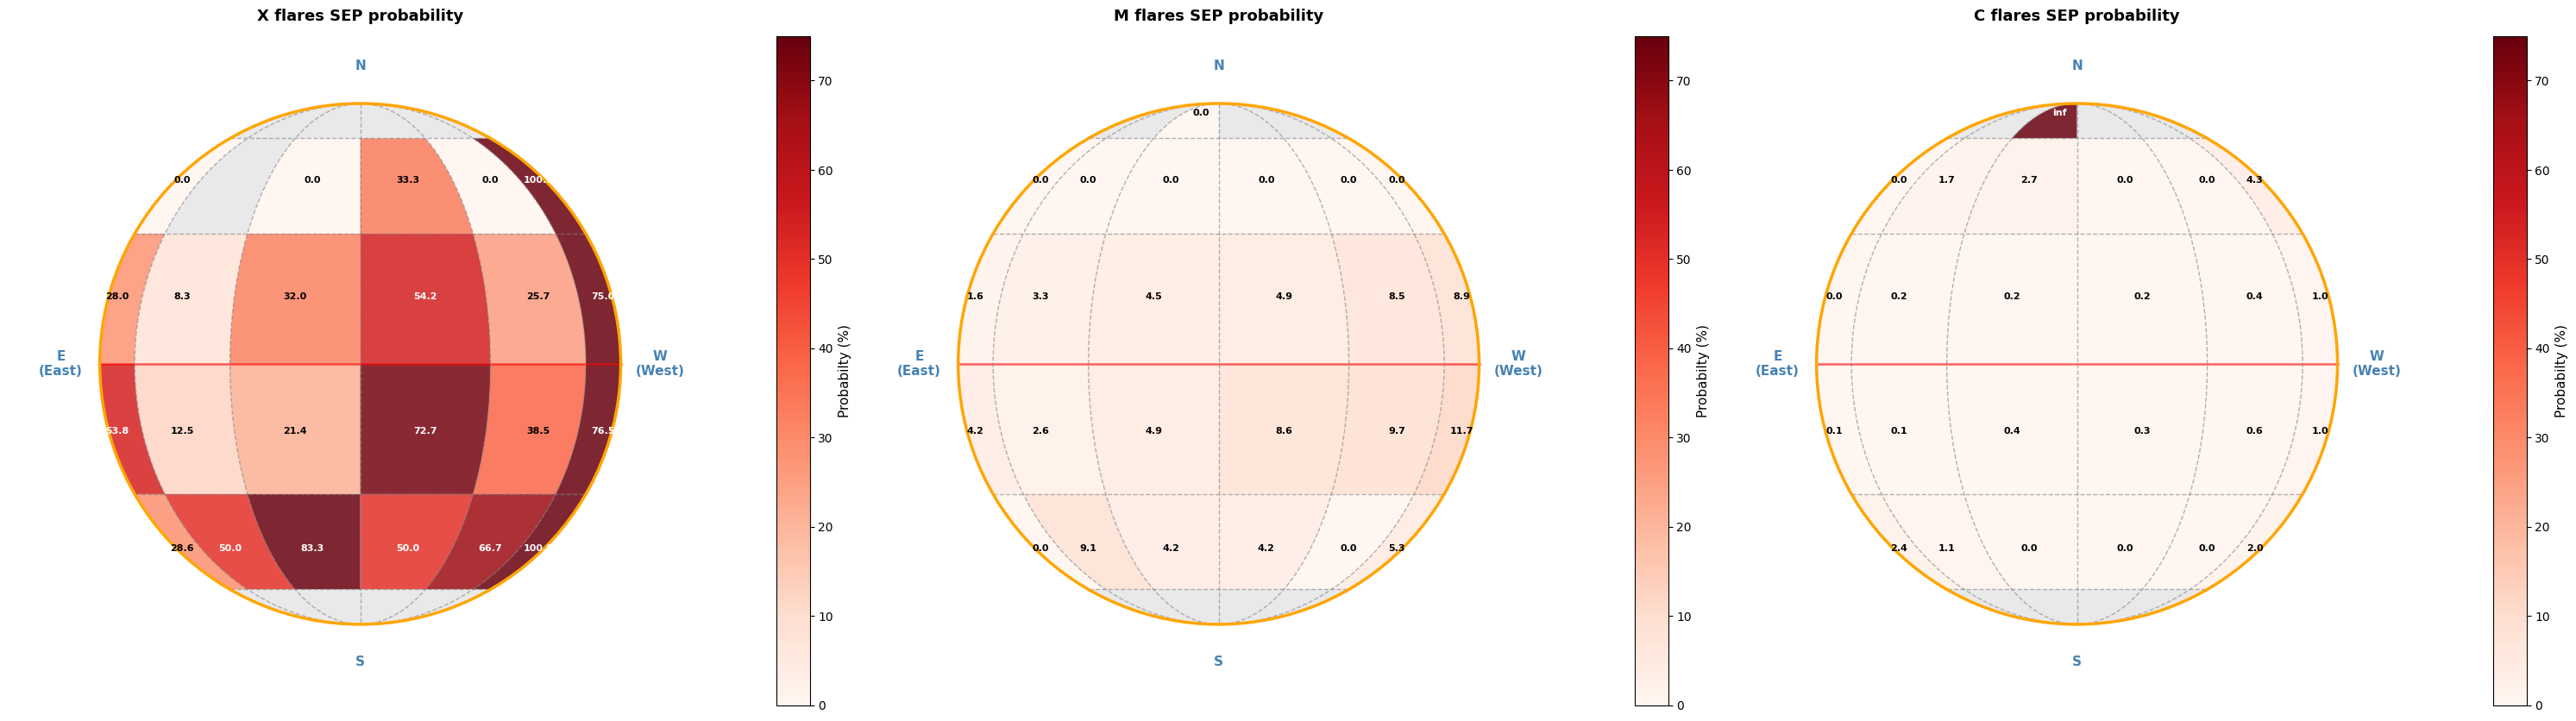

In [48]:
#%% NOAA

noaa_flares = dataset_reading.noaa_flares.dropna(subset=['lat_hg', 'long_hg', 'xray_class'])
date_debut = '1986-02-04'
date_fin = '2017-09-10'

noaa_flares = noaa_flares[
    (noaa_flares['time_start'] >= date_debut) & 
    (noaa_flares['time_start'] <= date_fin)
]

noaa_flares['long_hg'] = noaa_flares['long_hg'].clip(lower=-90, upper=90)

noaa_flares_X = noaa_flares[noaa_flares['xray_class'].str[0] == 'X']
noaa_flares_M = noaa_flares[noaa_flares['xray_class'].str[0] == 'M']
noaa_flares_C = noaa_flares[noaa_flares['xray_class'].str[0] == 'C']

x_C, y_C, _ = solarcoor2xy(noaa_flares_C['lat_hg'], noaa_flares_C['long_hg'])
x_M, y_M, _ = solarcoor2xy(noaa_flares_M['lat_hg'], noaa_flares_M['long_hg'])
x_X, y_X, _ = solarcoor2xy(noaa_flares_X['lat_hg'], noaa_flares_X['long_hg'])



#%% GSEP

GSEP_list_filtered = sep_dictionaries.GSEP_list.dropna(subset=['fl_lon', 'fl_lat'])


GSEP_xflares = GSEP_list_filtered[GSEP_list_filtered['fl_goes_class'].str.startswith('X')]
GSEP_mflares = GSEP_list_filtered[GSEP_list_filtered['fl_goes_class'].str.startswith('M')]
GSEP_cflares = GSEP_list_filtered[GSEP_list_filtered['fl_goes_class'].str.startswith('C')]


lat_x = GSEP_xflares['fl_lat']; long_x = GSEP_xflares['fl_lon'].clip(lower=-90, upper=90)
lat_m = GSEP_mflares['fl_lat']; long_m = GSEP_mflares['fl_lon'].clip(lower=-90, upper=90)
lat_c = GSEP_cflares['fl_lat']; long_c = GSEP_cflares['fl_lon'].clip(lower=-90, upper=90)

x_c, y_c, _ = solarcoor2xy(lat_c, long_c)
x_m, y_m, _ = solarcoor2xy(lat_m, long_m)
x_x, y_x, _ = solarcoor2xy(lat_x, long_x)

#%%

flares_grouped = [
    # (df_noaa, x_noaa, y_noaa, df_laur, x_laur, y_laur, title, color_noaa, color_laur)
    (noaa_flares_C, x_C, y_C, GSEP_cflares, x_c, y_c, 'C Flares', 'lemonchiffon',   'darkgoldenrod'),
    (noaa_flares_M, x_M, y_M, GSEP_mflares, x_m, y_m, 'M Flares', 'moccasin', 'darkorange'),
    (noaa_flares_X, x_X, y_X, GSEP_xflares, x_x, y_x, 'X Flares', 'lightcoral',    'darkred'),
]

#%%

fig, axes = plt.subplots(2, 6, figsize=(24, 8),
                         gridspec_kw={'width_ratios': [1, 1, 1, 4, 4,4],
                                      'height_ratios': [4, 1]})

fig.suptitle(
    "Spatial Distribution of Solar Flares by Class (C, M, X)\n dataset: NOAA Flares & GSEP",
    fontsize=16, fontweight='bold', y=1.02
)

for i, (df_n, x_n, y_n, df_l, x_l, y_l, title, c_n, c_l) in enumerate(flares_grouped):

    # ---- Plot du Soleil (colonnes 3,4,5) ----
    ax_sun = axes[0, i + 3]
    draw_sun_xy(x_n, y_n, title=title, color=c_n, ax=ax_sun, label='NOAA')
    draw_sun_xy(x_l, y_l, title=title, color=c_l, ax=ax_sun, label='GSEP')
    ax_sun.legend(fontsize=8)

    # # ---- Histogramme Latitude (colonnes 0,1,2) ----
    ax_lat = axes[0, i]
    bins_lat = np.arange(-100, 101, 5)
    ax_lat.hist(df_n['lat_hg'], bins=bins_lat, orientation='horizontal',
                color=c_n, alpha=0.6, label='NOAA')
    ax_lat.hist(df_l['fl_lat'], bins=bins_lat, orientation='horizontal',
                color=c_l, alpha=0.6, label='GSEP')
    ax_lat.axhline(y=np.mean(df_n['lat_hg']), color='black',     linestyle='-.', linewidth=1, label='mean NOAA')
    ax_lat.axhline(y=np.mean(df_l['fl_lat']), color='dimgray',   linestyle=':',  linewidth=1, label='mean GSEP.')
    ax_lat.set_ylim(-100, 100)
    ax_lat.axhline(y=90,  color='black', linestyle='-', linewidth=1)
    ax_lat.axhline(y=-90, color='black', linestyle='-', linewidth=1)
    ax_lat.set_title(f'Latitude {title}')
    ax_lat.set_ylabel('Latitude (°)')
    ax_lat.set_xlabel('Count')
    ax_lat.legend(fontsize=7)
    ax_lat.grid()

    # ---- Histogramme Longitude (colonnes 3,4,5 ligne du bas) ----
    ax_long = axes[1, i + 3]
    bins_long = np.arange(-100, 101, 5)
    ax_long.hist(df_n['long_hg'], bins=bins_long, orientation='vertical',
                 color=c_n, alpha=0.6, label='NOAA')
    ax_long.hist(df_l['fl_lon'], bins=bins_long, orientation='vertical',
                 color=c_l, alpha=0.6, label='Laurenza')
    ax_long.axvline(x=np.mean(df_n['long_hg']), color='black',   linestyle='-.', linewidth=1, label='mean NOAA')
    ax_long.axvline(x=np.mean(df_l['fl_lon']), color='dimgray', linestyle=':',  linewidth=2, label='mean Laur.')
    ax_long.set_xlim(-100, 100)
    ax_long.axvline(x=90,  color='black', linestyle='-', linewidth=1)
    ax_long.axvline(x=-90, color='black', linestyle='-', linewidth=1)
    ax_long.set_title(f'Longitude {title}')
    ax_long.set_xlabel('Longitude (°)')
    ax_long.set_ylabel('Count')
    ax_long.legend(fontsize=7, loc = 'upper left')
    ax_long.grid()

# Désactiver les axes vides du bas-gauche
for j in range(3):
    axes[1, j].axis('off')

plt.tight_layout()
plt.show()

#%%

fig, axes = plt.subplots(1, 3, figsize=(30, 10))

plot_sep_over_flare_probability(lat_x, long_x, noaa_flares_X['lat_hg'], noaa_flares_X['long_hg'], 
                                title='X flares SEP probability', ax=axes[0], vmax=75)
plot_sep_over_flare_probability(lat_m, long_m, noaa_flares_M['lat_hg'], noaa_flares_M['long_hg'], 
                                title='M flares SEP probability', ax=axes[1], vmax=75)
plot_sep_over_flare_probability(lat_c, long_c, noaa_flares_C['lat_hg'], noaa_flares_C['long_hg'], 
                                title='C flares SEP probability', ax=axes[2], vmax=75)

plt.tight_layout()
plt.show()

### Uncertainties

c:\Users\pierr\OneDrive - IPSA\Documents\IPSA\Aero 4\Stage A4\BIRA IASB Bruxelles\code\git-internship\usefull_functions.py:595: RuntimeWarning: divide by zero encountered in divide
  denom = 1 + (z**2) / n
c:\Users\pierr\OneDrive - IPSA\Documents\IPSA\Aero 4\Stage A4\BIRA IASB Bruxelles\code\git-internship\usefull_functions.py:596: RuntimeWarning: divide by zero encountered in divide
  center = (p + (z**2) / (2 * n)) / denom
c:\Users\pierr\OneDrive - IPSA\Documents\IPSA\Aero 4\Stage A4\BIRA IASB Bruxelles\code\git-internship\usefull_functions.py:598: RuntimeWarning: divide by zero encountered in divide
  (p * (1 - p) / n) + (z**2) / (4 * n**2)
c:\Users\pierr\OneDrive - IPSA\Documents\IPSA\Aero 4\Stage A4\BIRA IASB Bruxelles\code\git-internship\usefull_functions.py:596: RuntimeWarning: invalid value encountered in divide
  center = (p + (z**2) / (2 * n)) / denom
c:\Users\pierr\OneDrive - IPSA\Documents\IPSA\Aero 4\Stage A4\BIRA IASB Bruxelles\code\git-internship\usefull_functions.py:598

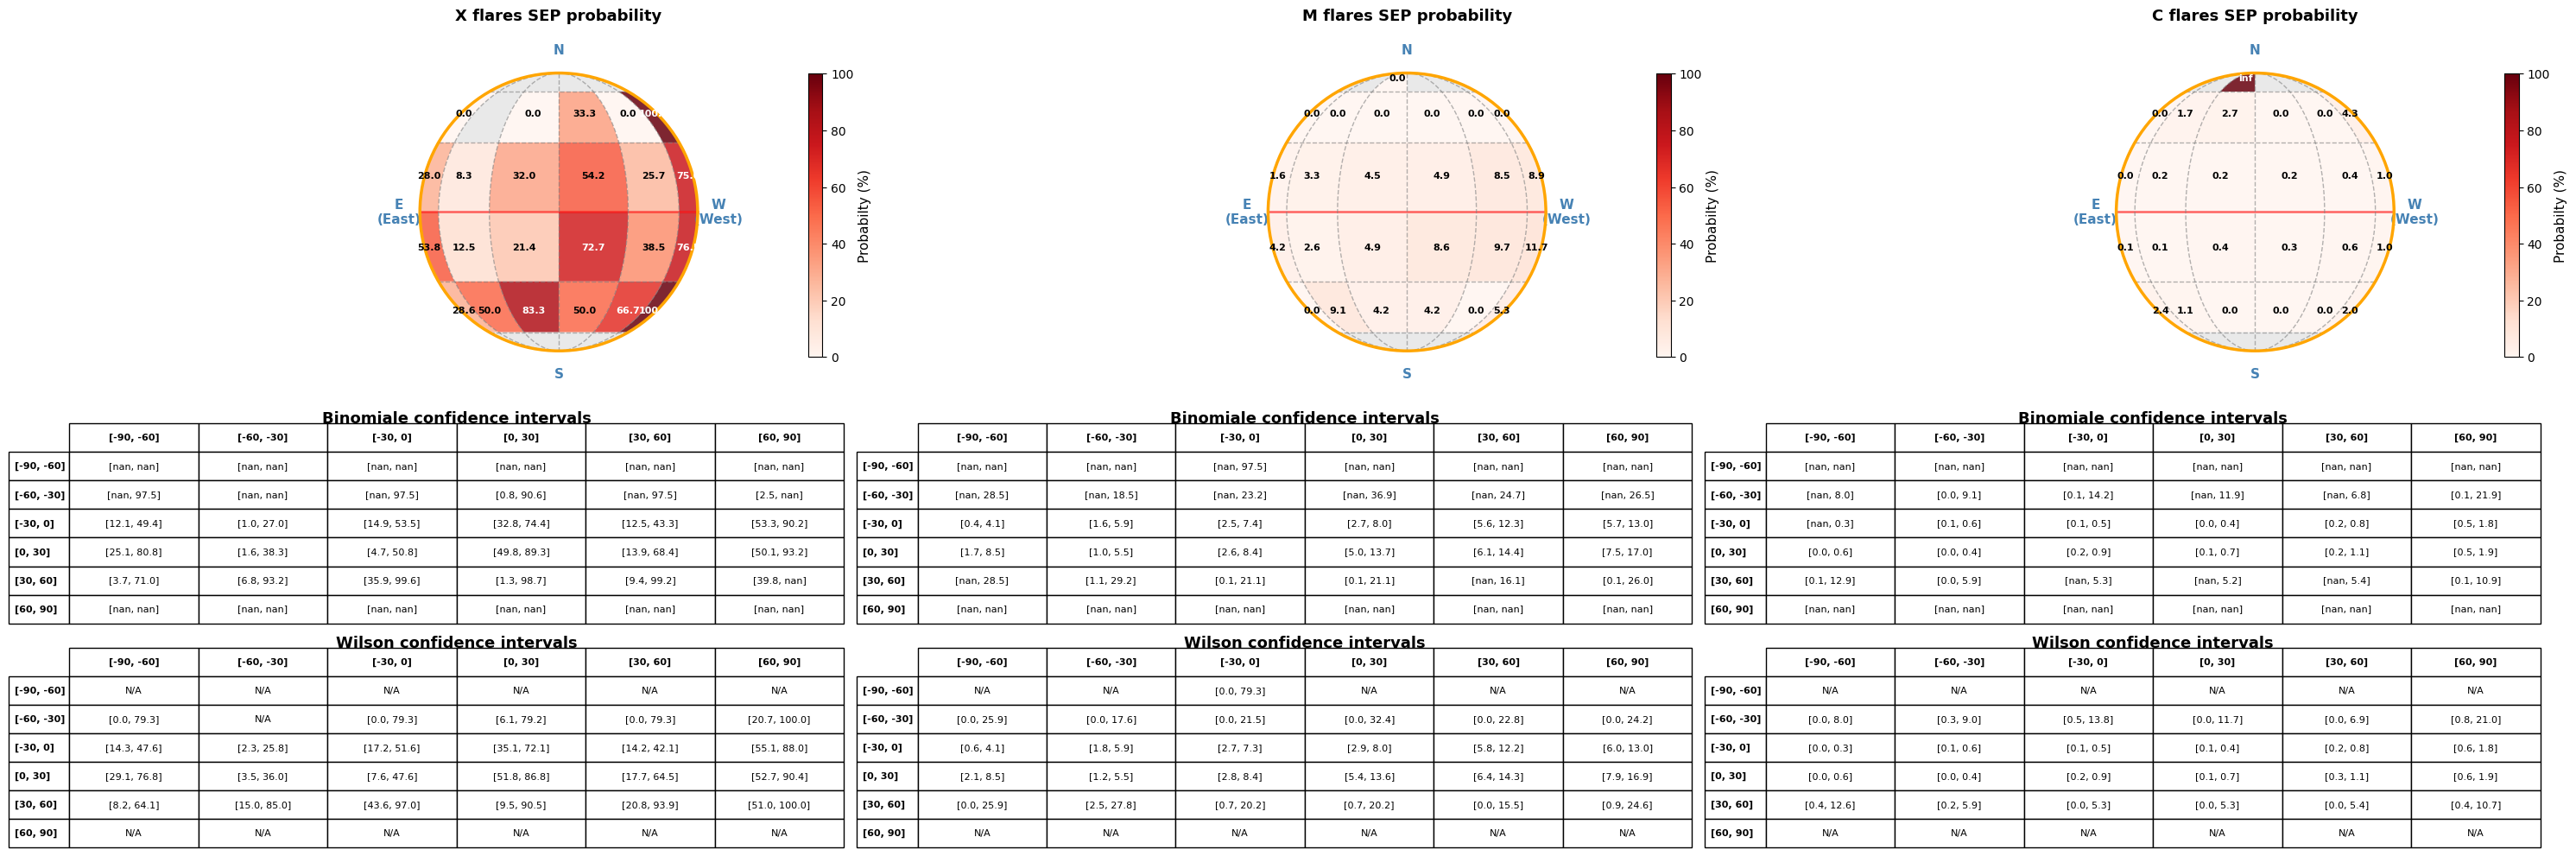

In [49]:
fig, axes = plt.subplots(3, 3, figsize=(30, 10), height_ratios=[1.9, 1, 1])

plot_sep_over_flare_probability(lat_x, long_x, noaa_flares_X['lat_hg'], noaa_flares_X['long_hg'], 
                                title='X flares SEP probability', ax=axes[0,0])

plot_sep_over_flare_probability(lat_m, long_m, noaa_flares_M['lat_hg'], noaa_flares_M['long_hg'], 
                                title='M flares SEP probability', ax=axes[0,1])
plot_sep_over_flare_probability(lat_c, long_c, noaa_flares_C['lat_hg'], noaa_flares_C['long_hg'], 
                                title='C flares SEP probability', ax=axes[0,2])

plot_sep_uncertainty(lat_x, long_x, noaa_flares_X['lat_hg'], noaa_flares_X['long_hg'],ax=axes[1,0])
plot_sep_uncertainty(lat_m, long_m, noaa_flares_M['lat_hg'], noaa_flares_M['long_hg'],ax=axes[1,1])
plot_sep_uncertainty(lat_c, long_c, noaa_flares_C['lat_hg'], noaa_flares_C['long_hg'],ax=axes[1,2])

plot_sep_uncertainty(lat_x, long_x, noaa_flares_X['lat_hg'], noaa_flares_X['long_hg'],ax=axes[2,0], type_uncertainty = 'wilson')
plot_sep_uncertainty(lat_m, long_m, noaa_flares_M['lat_hg'], noaa_flares_M['long_hg'],ax=axes[2,1], type_uncertainty = 'wilson')
plot_sep_uncertainty(lat_c, long_c, noaa_flares_C['lat_hg'], noaa_flares_C['long_hg'],ax=axes[2,2], type_uncertainty = 'wilson')

plt.tight_layout()
plt.show()


## For S-storms (GSEP)

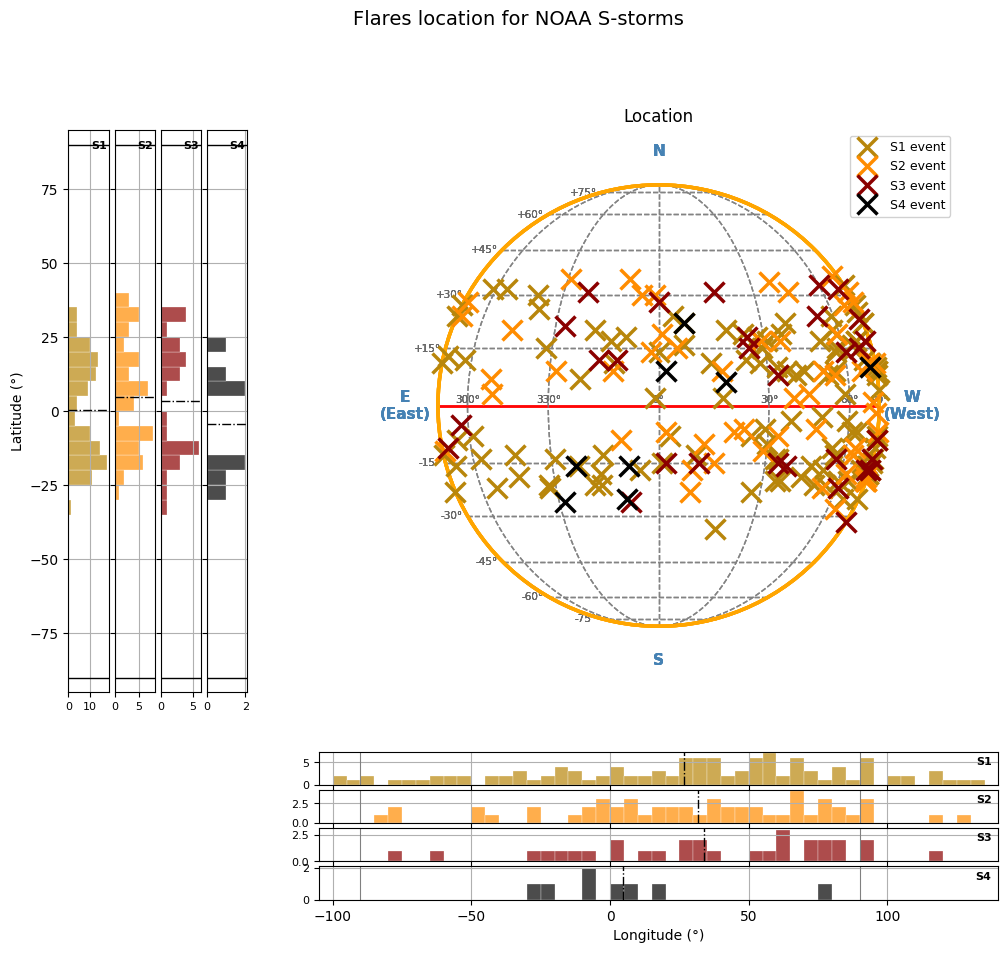

In [50]:
GSEP_list_filtered = sep_dictionaries.GSEP_list.dropna(subset=['fl_lon', 'fl_lat'])

GSEP_noaa_S1 = GSEP_list_filtered[
    (GSEP_list_filtered['noaa_pf10MeV'] >= 10) &
    (GSEP_list_filtered['noaa_pf10MeV'] < 100)
]
GSEP_noaa_S2 = GSEP_list_filtered[
    (GSEP_list_filtered['noaa_pf10MeV'] >= 100) &
    (GSEP_list_filtered['noaa_pf10MeV'] < 1000)
]
GSEP_noaa_S3 = GSEP_list_filtered[
    (GSEP_list_filtered['noaa_pf10MeV'] >= 1000) & 
    (GSEP_list_filtered['noaa_pf10MeV'] < 10000)
]
GSEP_noaa_S4 = GSEP_list_filtered[
    (GSEP_list_filtered['noaa_pf10MeV'] >= 10000)
]

lat_S1_90 = GSEP_noaa_S1['fl_lat']; long_S1_90 = GSEP_noaa_S1['fl_lon'].clip(lower=-90, upper=90)
lat_S2_90 = GSEP_noaa_S2['fl_lat']; long_S2_90 = GSEP_noaa_S2['fl_lon'].clip(lower=-90, upper=90)
lat_S3_90 = GSEP_noaa_S3['fl_lat']; long_S3_90 = GSEP_noaa_S3['fl_lon'].clip(lower=-90, upper=90)
lat_S4_90 = GSEP_noaa_S4['fl_lat']; long_S4_90 = GSEP_noaa_S4['fl_lon'].clip(lower=-90, upper=90)


lat_S1 = GSEP_noaa_S1['fl_lat']; long_S1 = GSEP_noaa_S1['fl_lon']
lat_S2 = GSEP_noaa_S2['fl_lat']; long_S2 = GSEP_noaa_S2['fl_lon']
lat_S3 = GSEP_noaa_S3['fl_lat']; long_S3 = GSEP_noaa_S3['fl_lon']
lat_S4 = GSEP_noaa_S4['fl_lat']; long_S4 = GSEP_noaa_S4['fl_lon']


x_S1, y_S1, _ = solarcoor2xy(lat_S1_90, long_S1_90)
x_S2, y_S2, _ = solarcoor2xy(lat_S2_90, long_S2_90)
x_S3, y_S3, _ = solarcoor2xy(lat_S3_90, long_S3_90)
x_S4, y_S4, _ = solarcoor2xy(lat_S4_90, long_S4_90)


colors = ['darkgoldenrod', 'darkorange', 'darkred', 'k']
labels = ['S1', 'S2', 'S3', 'S4']

lat_data = [lat_S1, lat_S2, lat_S3, lat_S4]
long_data = [long_S1, long_S2, long_S3, long_S4]

fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(4, 4, figure=fig, wspace=0.4, hspace=0.4)

# ---- Main sun plot ----
big_ax = fig.add_subplot(gs[0:3, 1:4])
for x, y, c, lab in zip([x_S1, x_S2, x_S3, x_S4],
                         [y_S1, y_S2, y_S3, y_S4],
                         colors, labels):
    draw_sun_xy(x, y, title='', color=c, ax=big_ax, label=f'{lab} event')
big_ax.set_title('Location', fontsize=12)
big_ax.grid(True)
big_ax.legend(loc='upper right', fontsize=9, framealpha=0.9)

bins = np.arange(-135, 156, 5)

# ---- Longitude histograms (bottom) ----
bottom_gs = gridspec.GridSpecFromSubplotSpec(
    4, 1, subplot_spec=gs[3, 1:4], hspace=0.15
)
long_axes = []
for i in range(4):
    ax = fig.add_subplot(bottom_gs[i], sharex=long_axes[0] if long_axes else None)
    long_axes.append(ax)
    ax.hist(long_data[i], bins=bins, color=colors[i], alpha=0.7,
             edgecolor='white', linewidth=0.3)
    mean_val = np.mean(long_data[i])
    ax.axvline(mean_val, color='black', linestyle='-.', linewidth=1)
    ax.axvline(90,  color='gray', linestyle='-', linewidth=0.8)
    ax.axvline(-90, color='gray', linestyle='-', linewidth=0.8)
    ax.set_xlim(-105, 140)
    ax.grid()
    ax.text(0.99, 0.85, labels[i], transform=ax.transAxes,
            ha='right', va='top', fontsize=8, fontweight='bold')
    if i < 3:
        plt.setp(ax.get_xticklabels(), visible=False)
    ax.tick_params(axis='y', labelsize=8)
long_axes[-1].set_xlabel('Longitude (°)', fontsize=10)

# ---- Latitude histograms (left) ----
left_gs = gridspec.GridSpecFromSubplotSpec(
    1, 4, subplot_spec=gs[0:3, 0], wspace=0.15
)
lat_axes = []
for i in range(4):
    ax = fig.add_subplot(left_gs[i], sharey=lat_axes[0] if lat_axes else None)
    lat_axes.append(ax)
    ax.hist(lat_data[i], bins=bins, orientation='horizontal',
             color=colors[i], alpha=0.7, edgecolor='white', linewidth=0.3)
    mean_val = np.mean(lat_data[i])
    ax.axhline(mean_val, color='black', linestyle='-.', linewidth=1)
    ax.axhline(90,  color='black', linestyle='-', linewidth=1)
    ax.axhline(-90, color='black', linestyle='-', linewidth=1)
    ax.set_ylim(-95, 95)
    ax.grid()
    ax.text(0.95, 0.98, labels[i], transform=ax.transAxes,
            ha='right', va='top', fontsize=8, fontweight='bold')
    if i > 0:
        plt.setp(ax.get_yticklabels(), visible=False)
    ax.tick_params(axis='x', labelsize=8)
lat_axes[0].set_ylabel('Latitude (°)', fontsize=10)

plt.suptitle('Flares location for NOAA S-storms', y=1.0, fontsize=14)
plt.show()


# Timeline SEP event (CDAW Extended Database)

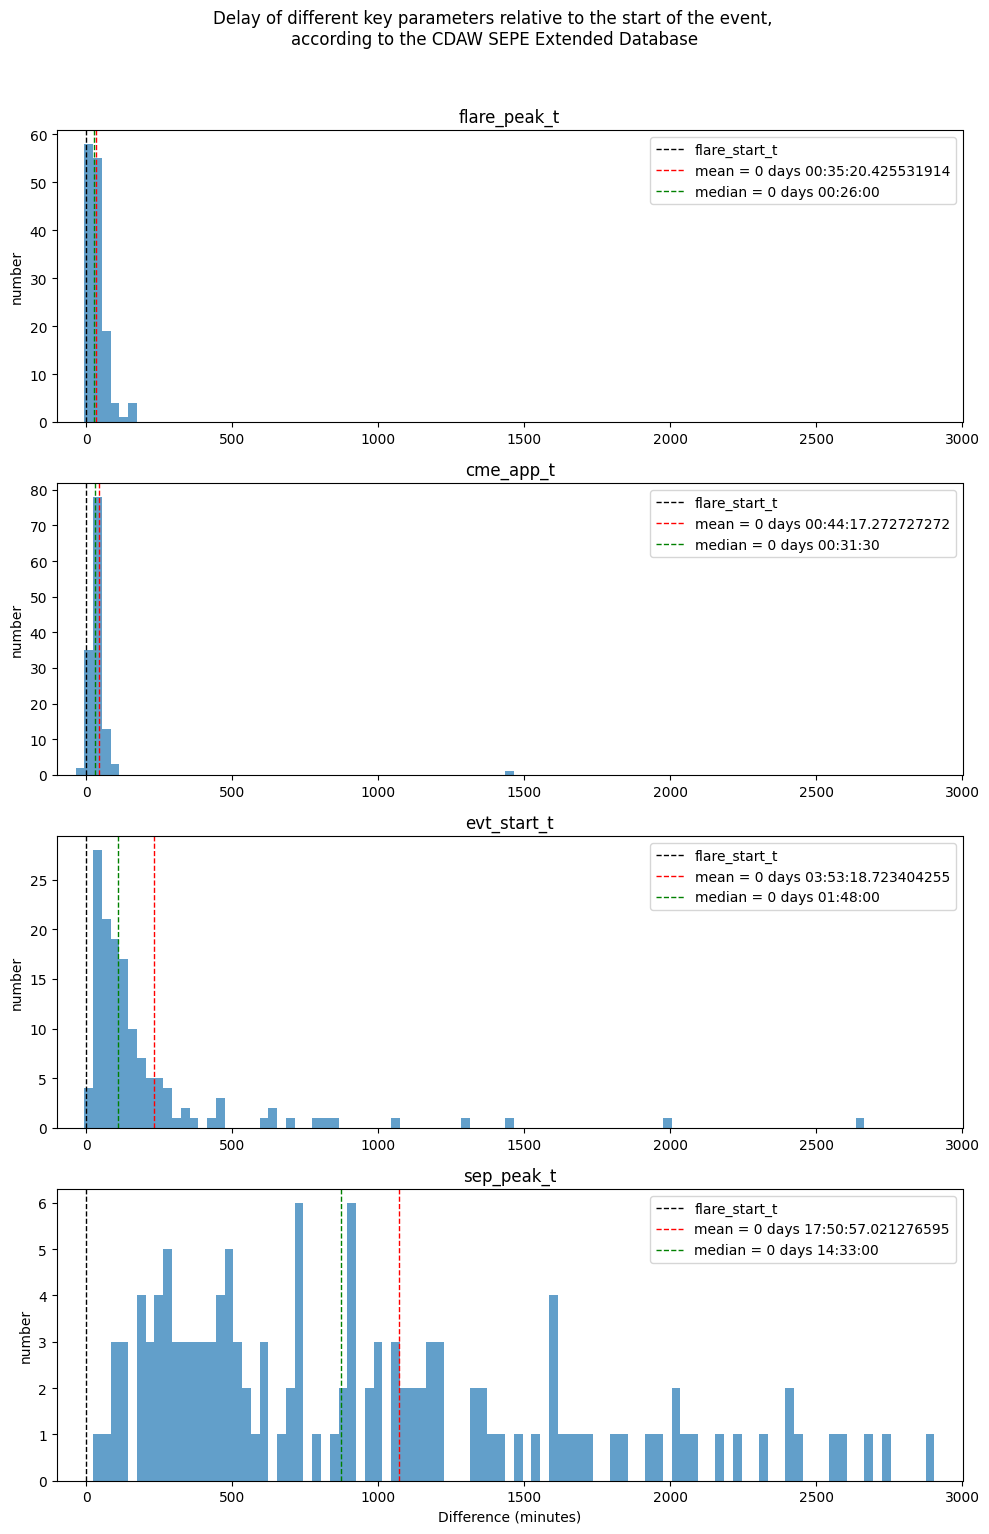

In [51]:
cdaw_sepe_extented =  dataset_reading.cdaw_sepe_extented

evt_start_t = cdaw_sepe_extented['evt_start_t']
evt_peak_t = cdaw_sepe_extented['evt_peak_t']
sep_peak_t = cdaw_sepe_extented['sep_peak_t']
cme_app_t = cdaw_sepe_extented['cme_app_t']
flare_start_t = cdaw_sepe_extented['flare_start_t']
flare_peak_t = cdaw_sepe_extented['flare_peak_t']


all_lists = {
    'evt_start_t': evt_start_t,
    'evt_peak_t': evt_peak_t,
    'sep_peak_t': sep_peak_t,
    'cme_app_t': cme_app_t,
    'flare_start_t': flare_start_t,
    'flare_peak_t': flare_peak_t,
}

comparisons = {
    'flare_peak_t': flare_peak_t,
    'cme_app_t': cme_app_t,
    'evt_start_t': evt_start_t,
    'sep_peak_t': sep_peak_t,
}


all_diffs = {}
global_min = 0
global_max = 0

for name, data in comparisons.items():
    mean, df_clean, median = time_mean(flare_start_t, data)
    diff_minutes = df_clean['difference'].dt.total_seconds() / 60
    all_diffs[name] = (diff_minutes, mean)
    global_min = min(global_min, diff_minutes.min())
    global_max = max(global_max, diff_minutes.max())

fig, axes = plt.subplots(nrows=4, ncols=1, figsize = (10,15), sharex=False)

for ax, (name, data) in zip(axes, comparisons.items()):
    mean, df_clean, median = time_mean(flare_start_t, data)
    
    diff_minutes = df_clean['difference'].dt.total_seconds() / 60
    
    ax.hist(diff_minutes, bins=np.arange(global_min, global_max + 30, 30), alpha=0.7)
    #ax.set_xscale('log') 
    ax.set_title(f'{name}')
    ax.set_ylabel('number')
    ax.axvline(0, color='black', linestyle='--', linewidth=1, label='flare_start_t')
    ax.axvline(mean.total_seconds() / 60, color='red', linestyle='--', linewidth=1, label=f'mean = {mean}')
    ax.axvline(median.total_seconds() / 60, color='green', linestyle='--', linewidth=1, label=f'median = {median}')
    ax.set_xlim(-100, 3000)
    ax.legend()
   

axes[-1].set_xlabel('Difference (minutes)')

plt.suptitle('Delay of different key parameters relative to the start of the event, \naccording to the CDAW SEPE Extended Database', 
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [52]:
names = ['evt_start_t', 'sep_peak_t', 'cme_app_t', 'flare_start_t', 'flare_peak_t']
all_dt = {name: pd.to_datetime(lst) for name, lst in all_lists.items()}
combinations = []


for i in range(172):
    event = [(name, all_dt[name][i]) for name in names]
    
    if any(pd.isna(date) for _, date in event):
        continue
    
    event_sorted = sorted(event, key=lambda x: x[1])
    
    combo = ' >> '.join(name for name, _ in event_sorted)
    combinations.append(combo)

counter = Counter(combinations)
total = len(combinations)

results = sorted(counter.items(), key=lambda x: x[1])

print(f"Number of valid events: {total}\n")
for combo, count in results:
    pct = count / total * 100
    print(f"{pct:5.1f}%  ({count:3d})  {combo}")

Number of valid events: 133

  0.8%  (  1)  flare_start_t >> cme_app_t >> evt_start_t >> sep_peak_t >> flare_peak_t
  1.5%  (  2)  cme_app_t >> flare_start_t >> flare_peak_t >> evt_start_t >> sep_peak_t
  1.5%  (  2)  sep_peak_t >> flare_start_t >> flare_peak_t >> cme_app_t >> evt_start_t
  2.3%  (  3)  flare_start_t >> flare_peak_t >> evt_start_t >> sep_peak_t >> cme_app_t
  3.8%  (  5)  flare_start_t >> flare_peak_t >> evt_start_t >> cme_app_t >> sep_peak_t
  3.8%  (  5)  flare_start_t >> cme_app_t >> evt_start_t >> flare_peak_t >> sep_peak_t
 38.3%  ( 51)  flare_start_t >> cme_app_t >> flare_peak_t >> evt_start_t >> sep_peak_t
 48.1%  ( 64)  flare_start_t >> flare_peak_t >> cme_app_t >> evt_start_t >> sep_peak_t


In [53]:
names = ['sep_peak_t', 'evt_peak_t']    # /!\ attention if it's equal, it's the first written terms that will be first 
all_dt = {name: pd.to_datetime(lst) for name, lst in all_lists.items()}
combinations = []


for i in range(172):
    event = [(name, all_dt[name][i]) for name in names]
    
    if any(pd.isna(date) for _, date in event):
        continue
    
    event_sorted = sorted(event, key=lambda x: x[1])
    
    combo = ' >> '.join(name for name, _ in event_sorted)
    combinations.append(combo)

counter = Counter(combinations)
total = len(combinations)

results = sorted(counter.items(), key=lambda x: x[1])

print(f"Number of valid events: {total}\n")
for combo, count in results:
    pct = count / total * 100
    print(f"{pct:5.1f}%  ({count:3d})  {combo}")

Number of valid events: 172

  0.6%  (  1)  evt_peak_t >> sep_peak_t
 99.4%  (171)  sep_peak_t >> evt_peak_t


In [54]:
names = ['evt_peak_t', 'sep_peak_t']    # /!\ attention if it's equal, it's the first written terms that will be first 
all_dt = {name: pd.to_datetime(lst) for name, lst in all_lists.items()}
combinations = []


for i in range(172):
    event = [(name, all_dt[name][i]) for name in names]
    
    if any(pd.isna(date) for _, date in event):
        continue
    
    event_sorted = sorted(event, key=lambda x: x[1])
    
    combo = ' >> '.join(name for name, _ in event_sorted)
    combinations.append(combo)

counter = Counter(combinations)
total = len(combinations)

results = sorted(counter.items(), key=lambda x: x[1])

print(f"Number of valid events: {total}\n")
for combo, count in results:
    pct = count / total * 100
    print(f"{pct:5.1f}%  ({count:3d})  {combo}")

Number of valid events: 172

 16.9%  ( 29)  sep_peak_t >> evt_peak_t
 83.1%  (143)  evt_peak_t >> sep_peak_t


# Solar Cycle (and Sunspot number)

C:\Users\pierr\AppData\Local\Temp\ipykernel_35804\4089873636.py:20: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  solar_cycle = pd.read_csv("C:/Users/pierr/OneDrive - IPSA/Documents/IPSA/Aero 4/Stage A4/BIRA IASB Bruxelles/dataset/sunspot/SN_ms_tot_V2.0.csv", names= ['year','month', 'decimal_year', 'SNvalue' , 'SNerror', 'Nb observations'],index_col=False, sep = ";")


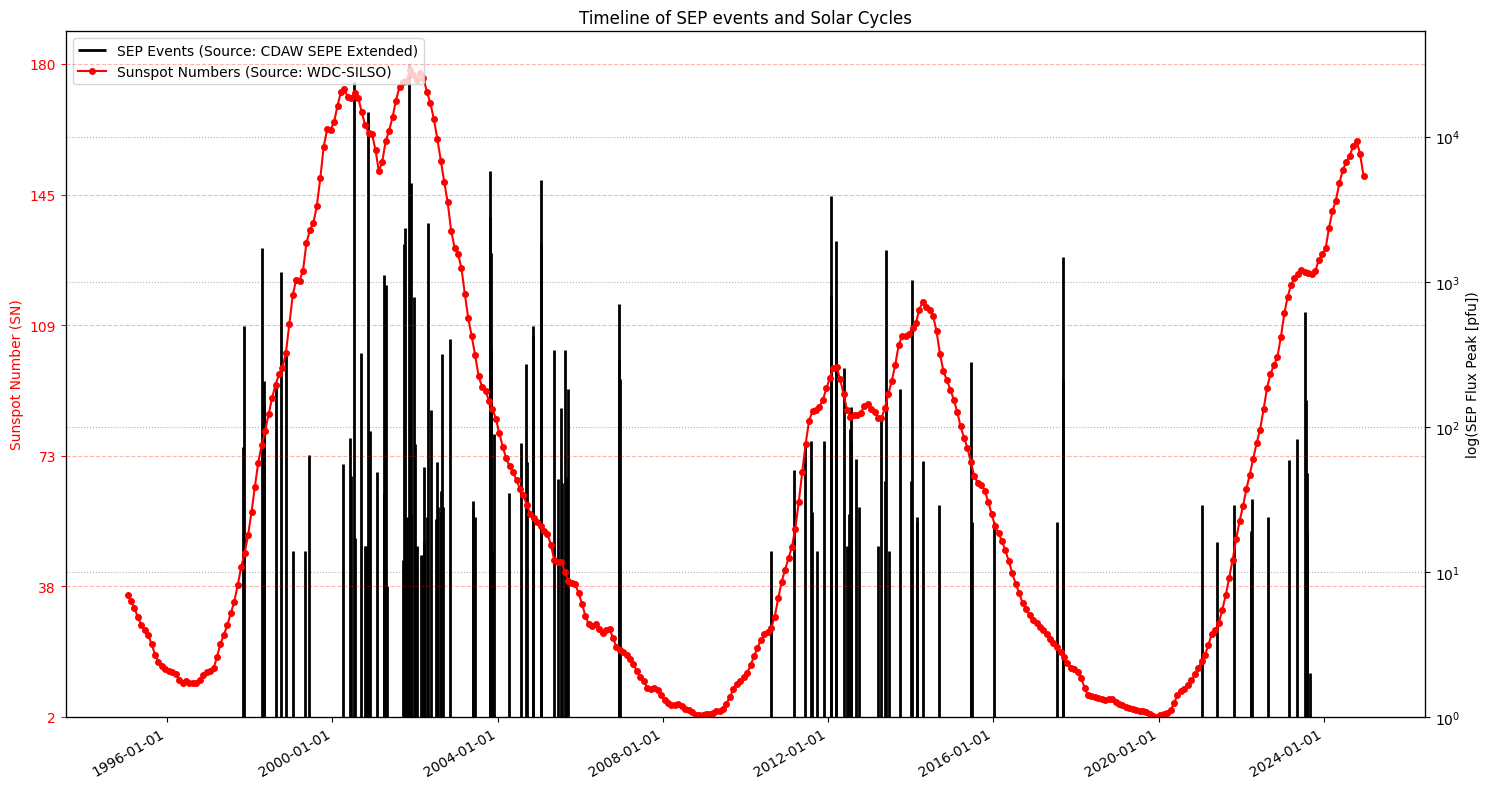

In [55]:
GSEP_list = dataset_reading.GSEP_list.dropna(subset = ['timestamp'])
timestamp = GSEP_list['timestamp']


sep_dates_GSEP = [datetime.strptime(str(date), '%Y-%m-%d %H:%M:%S') for date in timestamp]


cdaw_sepe_extented = dataset_reading.cdaw_sepe_extented.dropna(subset = ['flare_peak_t', 'sep_peak_f']) 
flare_peak_t = cdaw_sepe_extented['flare_peak_t']
sep_dates = [datetime.strptime(str(date), '%Y-%m-%d %H:%M:%S') for date in flare_peak_t]
sep_peak_f = cdaw_sepe_extented['sep_peak_f']  


log_sep_peak_f = np.log(sep_peak_f)
log_sep_peak_f_cr = (log_sep_peak_f - min(log_sep_peak_f))/(max(log_sep_peak_f)-min(log_sep_peak_f))


#-------------------------------------------------------------
sys.path.append("C:/Users/pierr/OneDrive - IPSA/Documents/IPSA/Aero 4/Stage A4/BIRA IASB Bruxelles/dataset/sunspot")
solar_cycle = pd.read_csv("C:/Users/pierr/OneDrive - IPSA/Documents/IPSA/Aero 4/Stage A4/BIRA IASB Bruxelles/dataset/sunspot/SN_ms_tot_V2.0.csv", names= ['year','month', 'decimal_year', 'SNvalue' , 'SNerror', 'Nb observations'],index_col=False, sep = ";")
#"Source: WDC-SILSO, Royal Observatory of Belgium, Brussels, DOI: https://doi.org/10.24414/qnza-ac80 ” --> https://www.sidc.be/SILSO/newdataset.


solar_cycle = solar_cycle[solar_cycle["year"] > 1994]
solar_cycle = solar_cycle[ solar_cycle["year"] < 2025]
solar_cycle = solar_cycle[["decimal_year", "SNvalue"]]



def decimal_year_to_date(y):
    year = int(y)
    rem = y - year
    base = datetime(year, 1, 1)
    return base + (datetime(year+1,1,1) - base) * rem

dates_sn = [decimal_year_to_date(float(y)) for y in solar_cycle['decimal_year']]


sn_number_cr = (solar_cycle['SNvalue'] - min(solar_cycle['SNvalue']))/max(solar_cycle['SNvalue'])


#-------------------------------------------------------------

fig, ax = plt.subplots(figsize=(15, 8))

# ---- Données SEP (lignes verticales) en valeurs normalisées ----
ax.vlines(sep_dates, ymin=0, ymax=log_sep_peak_f_cr,
          color='black', label = 'SEP Events (Source: CDAW SEPE Extended)' , linestyle='-', linewidth=2, zorder=3)

# ---- Données SN (courbe rouge) en valeurs normalisées ----
ax.plot(dates_sn, sn_number_cr, 'r-o', label='Sunspot Numbers (Source: WDC-SILSO)', markersize=4, zorder=4)

ax.set_ylim(0, 1.05)
ax.set_yticks([])
#-------------------------SUNSPOT NUMBER (SN)-------------------------------------------------------------
ax_sn = ax.twinx()
ax_sn.spines['left'].set_position(('outward', 0))
ax_sn.yaxis.set_label_position('left')
ax_sn.yaxis.set_ticks_position('left')

# On veut afficher les vraies valeurs SN aux positions normalisées
sn_color = 'red'
# graduations linéaires sur les vraies valeurs
sn_ticks_real = np.linspace(min(solar_cycle['SNvalue']),max(solar_cycle['SNvalue']), 6)
# positions normalisées correspondantes
sn_ticks_norm = (sn_ticks_real - min(solar_cycle['SNvalue'])) / (max(solar_cycle['SNvalue']) -min(solar_cycle['SNvalue']))

ax_sn.set_ylim(0, 1.05)
ax_sn.set_yticks(sn_ticks_norm)
ax_sn.set_yticklabels([f"{v:.0f}" for v in sn_ticks_real])
ax_sn.set_ylabel("Sunspot Number (SN)", color=sn_color)
ax_sn.tick_params(axis='y', colors=sn_color)
ax_sn.grid(True, axis='y', color=sn_color, alpha=0.3, linestyle='--')

#----------------------------SEP EVENTS-----------------------------------------------------------
ax_sep = ax.twinx()
ax_sep.yaxis.set_label_position('right')
ax_sep.yaxis.set_ticks_position('right')

sep_color = 'black'
sep_color_2 = 'blue'
sep_min = min(sep_peak_f)
sep_max = max(sep_peak_f)

# graduations log sur les vraies valeurs
log_min = np.log10(sep_min)
log_max = np.log10(sep_max)
# décades entières dans l'intervalle
decades = np.arange(np.floor(log_min), np.ceil(log_max) + 1)
sep_ticks_real = 10.0 ** decades

# conversion des vraies valeurs vers la position normalisée
# normalisation utilisée sur le graphe = (ln(f) - min(ln f)) / (max - min)
def real_to_norm(f):
    return (np.log(f) - min(log_sep_peak_f)) / (max(log_sep_peak_f) - min(log_sep_peak_f))

sep_ticks_norm = real_to_norm(sep_ticks_real)

# on ne garde que les ticks dans [0, 1]
mask = (sep_ticks_norm >= 0) & (sep_ticks_norm <= 1.05)
sep_ticks_norm = sep_ticks_norm[mask]
sep_ticks_real = sep_ticks_real[mask]

ax_sep.set_ylim(0, 1.05)
ax_sep.set_yticks(sep_ticks_norm)
ax_sep.set_yticklabels([f"$10^{{{int(np.log10(v))}}}$" for v in sep_ticks_real])
ax_sep.set_ylabel("log(SEP Flux Peak [pfu])", color=sep_color)
ax_sep.tick_params(axis='y', colors=sep_color)
ax_sep.grid(True, axis='y', color=sep_color, alpha=0.3, linestyle=':')

#---------------------------------------------------------------------------------------
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()
ax.set_title("Timeline of SEP events and Solar Cycles")

# légende combinée
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [56]:
# ============================================================
# 1. Séries SEP agrégées par mois (plusieurs métriques)
# ============================================================
sep_df = pd.DataFrame({'date': sep_dates, 'flux': sep_peak_f.values})
sep_df = sep_df.set_index('date')

sep_monthly_count  = sep_df['flux'].resample('MS').count()         # nombre d'événements
sep_monthly_sum    = sep_df['flux'].resample('MS').sum()           # flux cumulé
sep_monthly_logsum = np.log10(sep_df['flux']).resample('MS').sum() # robuste aux outliers

# ============================================================
# 2. SN sur le même index mensuel
# ============================================================
sn_df = pd.DataFrame({'date': dates_sn, 'sn': solar_cycle['SNvalue'].values})
sn_df = sn_df.set_index('date')
sn_monthly = sn_df['sn'].resample('MS').mean()

# ============================================================
# 3. Un SEUL DataFrame avec toutes les colonnes
# ============================================================
corr_parameters = pd.concat(
    [sn_monthly, sep_monthly_count, sep_monthly_sum, sep_monthly_logsum],
    axis=1
).fillna(0)
corr_parameters.columns = ['sn', 'sep_count', 'sep_sum', 'sep_logsum']

The Pearson correlation coefficient is probably the best-known correlation coefficient in statistics. It measures the strength of the linear link between two quantitative variables. Its value varies between -1 and 1:

1: perfect positive correlation: when one variable increases, the other increases.

0: no correlation.

-1: perfect negative correlation: when one variable increases, the other decreases.

In [57]:
print_corr(corr_parameters, 'sn', 'sep_count',     "SN vs SEP count monthly")
print_corr(corr_parameters, 'sn', 'sep_sum',       "SN vs SEP cumulated flux")
print_corr(corr_parameters, 'sn', 'sep_logsum',    "SN vs SEP cumulated log-flux")

SN vs SEP count monthly
  Pearson  r = +0.342 (p=2.53e-11)
  Spearman r = +0.384 (p=4.60e-14)
---------------------------------------------------
SN vs SEP cumulated flux
  Pearson  r = +0.200 (p=1.29e-04)
  Spearman r = +0.384 (p=4.29e-14)
---------------------------------------------------
SN vs SEP cumulated log-flux
  Pearson  r = +0.309 (p=2.08e-09)
  Spearman r = +0.383 (p=5.24e-14)
---------------------------------------------------


(np.float64(0.30909098810569013),
 np.float64(2.078673740011714e-09),
 np.float64(0.38277249855005135),
 np.float64(5.2368941348134784e-14))

In [58]:
windows = range(4, 25, 2)  #cumulative months tests 

for w in windows:
    corr_parameters[f'sep_count_{w}m'] = (
        corr_parameters['sep_count']
        .rolling(window=w, min_periods=1)
        .sum()
        .astype(int)
    )
    
    
results = []

for w in windows:
    col = f'sep_count_{w}m'
    r_p, p_p = pearsonr(corr_parameters['sn'], corr_parameters[col])
    r_s, p_s = spearmanr(corr_parameters['sn'], corr_parameters[col])
    results.append({
        'window_months': w,
        'pearson_r':  round(r_p,4),
        'pearson_p':  round(p_p,10),
        'spearman_r': round(r_s,4),
        'spearman_p': round(p_s,10)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 window_months  pearson_r  pearson_p  spearman_r  spearman_p
             4     0.5297        0.0      0.5919         0.0
             6     0.5876        0.0      0.6560         0.0
             8     0.6163        0.0      0.6826         0.0
            10     0.6352        0.0      0.7036         0.0
            12     0.6459        0.0      0.7184         0.0
            14     0.6550        0.0      0.7360         0.0
            16     0.6619        0.0      0.7523         0.0
            18     0.6591        0.0      0.7493         0.0
            20     0.6490        0.0      0.7376         0.0
            22     0.6362        0.0      0.7210         0.0
            24     0.6221        0.0      0.7036         0.0


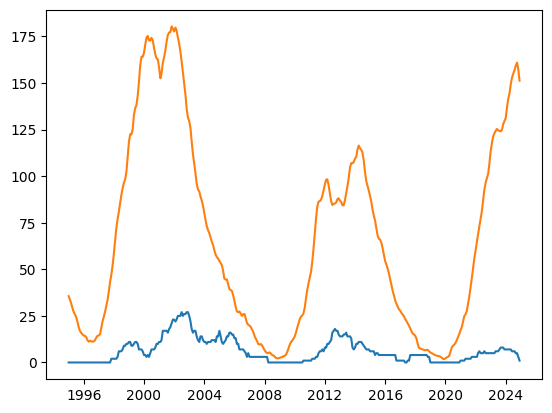

In [59]:
plt.plot(corr_parameters['sep_count_16m'])
plt.plot(corr_parameters['sn'])

# Dictionaries creation (reading from dataset_reading)

In [60]:
sep_dictionary = sep_dictionaries.sep_dictionary

cdaw_sep_dictionary = sep_dictionaries.cdaw_sep_dictionary

cme_sep_dictionary = sep_dictionaries.cdaw_sep_dictionary

complete_sep_dictionary = sep_dictionaries.cdaw_sep_dictionary

best_sep_dictionary = sep_dictionaries.cdaw_sep_dictionary


S0_ZPGT10W_CORR_sep_dictionary = sep_dictionaries.S0_ZPGT10W_CORR_sep_dictionary
S1_ZPGT10W_CORR_sep_dictionary = sep_dictionaries.S1_ZPGT10W_CORR_sep_dictionary
S2_ZPGT10W_CORR_sep_dictionary = sep_dictionaries.S2_ZPGT10W_CORR_sep_dictionary 
S3_ZPGT10W_CORR_sep_dictionary = sep_dictionaries.S3_ZPGT10W_CORR_sep_dictionary
S4_ZPGT10W_CORR_sep_dictionary = sep_dictionaries.S4_ZPGT10W_CORR_sep_dictionary
S0_noaa_pf10MeV_sep_dictionary = sep_dictionaries.S0_noaa_pf10MeV_sep_dictionary
S1_noaa_pf10MeV_sep_dictionary = sep_dictionaries.S1_noaa_pf10MeV_sep_dictionary
S2_noaa_pf10MeV_sep_dictionary = sep_dictionaries.S2_noaa_pf10MeV_sep_dictionary 
S3_noaa_pf10MeV_sep_dictionary = sep_dictionaries.S3_noaa_pf10MeV_sep_dictionary
S4_noaa_pf10MeV_sep_dictionary = sep_dictionaries.S4_noaa_pf10MeV_sep_dictionary
S0_ppf_gt10MeV_sep_dictionary = sep_dictionaries.S0_ppf_gt10MeV_sep_dictionary
S1_ppf_gt10MeV_sep_dictionary = sep_dictionaries.S1_ppf_gt10MeV_sep_dictionary 
S2_ppf_gt10MeV_sep_dictionary = sep_dictionaries.S2_ppf_gt10MeV_sep_dictionary
S3_ppf_gt10MeV_sep_dictionary = sep_dictionaries.S3_ppf_gt10MeV_sep_dictionary
S4_ppf_gt10MeV_sep_dictionary = sep_dictionaries.S4_ppf_gt10MeV_sep_dictionary


           ZPGT10W   |   NOAA   |    PPF   |
---------------------------------------------------
    S0  |   168      |      1   |    101   |   
    S1  |   144      |    128   |    116   | 
    S2  |    65      |     54   |     55   | 
    S3  |    36      |     30   |     27   | 
    S4  |    10      |      7   |      7   | 
---------------------------------------------------
            423      |    220   |    306   |   

# SEP Timeline

In [61]:
cols = [f'max_F{i}' for i in range(1, 12)] + ['max_x_ray']
rows = []
for key, df in sep_dictionary.items():
    if len(df) > 0 and all(col in df.columns for col in cols):
        row = {'date': key}
        row.update({col: df[col].iloc[0] for col in cols})
        rows.append(row)

base_df = pd.DataFrame(rows)

for i in range(1, 12):
    col_tri = f'max_F{i}'
    df_sorted = base_df.sort_values(by=col_tri, ascending=False).reset_index(drop=True)
    globals()[f'result_max_F{i}'] = df_sorted
result_max_x_ray = base_df.sort_values(by='max_x_ray', ascending=False).reset_index(drop=True)


del base_df, col_tri, cols, df, df_sorted, i, key, row, rows

In [62]:
columns = ['time_max_x_ray'] + [f'time_max_F{i}' for i in range(1, 12)]

results = {}

for reference_timestamp, df in sep_dictionary.items():
    if df.empty:
        continue
    
    row = {}
    skip_event = False
    
    for col in columns:
        try:
            col_value = df[col].iloc[0]
        except IndexError:
            skip_event = True
            break
        
        mean, _, _ = time_mean(
            pd.Series([reference_timestamp]),
            pd.Series([col_value]),
            diff_max=20
        )
        
        row[col] = mean
    
    if not skip_event:
        results[reference_timestamp] = row

# Création du dataframe final
result_df = pd.DataFrame.from_dict(results, orient='index', columns=columns)
result_df.index.name = 'reference_timestamp'

# --- Calcul des statistiques par colonne ---

stats = {}
for col in columns:
    col_data = result_df[col].dropna()
    col_minutes = col_data.dt.total_seconds() / 60  # Conversion en minutes
    
    stats[col] = {
        'mean_min'     : col_minutes.mean(),
        'median_min'   : col_minutes.median(),
        'variance_min2' : col_minutes.var()
    }

# Création du dataframe des statistiques (3 lignes x 12 colonnes)
stats_df = pd.DataFrame.from_dict(stats, orient='columns').reindex(['mean_min', 'median_min', 'variance_min2'])
stats_df.index.name = 'reference_timestamp'

# Concaténation : stats_df en haut, result_df en dessous
result_df = pd.concat([stats_df, result_df])

del col, col_data, col_minutes, col_value, columns, df, mean, reference_timestamp, results, row, skip_event, stats


print(stats_df.head())

                     time_max_x_ray    time_max_F1    time_max_F2  \
reference_timestamp                                                 
mean_min                  197.12766     827.399527     767.115839   
median_min                -55.00000     800.000000     670.000000   
variance_min2          547154.94101  504536.230995  445246.993658   

                       time_max_F3    time_max_F4    time_max_F5  \
reference_timestamp                                                
mean_min                702.659574     634.290780     568.770686   
median_min              565.000000     485.000000     415.000000   
variance_min2        398123.419381  384211.581123  383053.106058   

                       time_max_F6    time_max_F7    time_max_F8  \
reference_timestamp                                                
mean_min                401.513002     188.794326    -156.619385   
median_min              285.000000     135.000000     -25.000000   
variance_min2        505371.283598  60676

# SEP Timeseries Visualisation

<Axes: title={'center': 'X ray flux, F[1, 2] & >10MeV '}, ylabel='X-ray flux (W/m²)'>

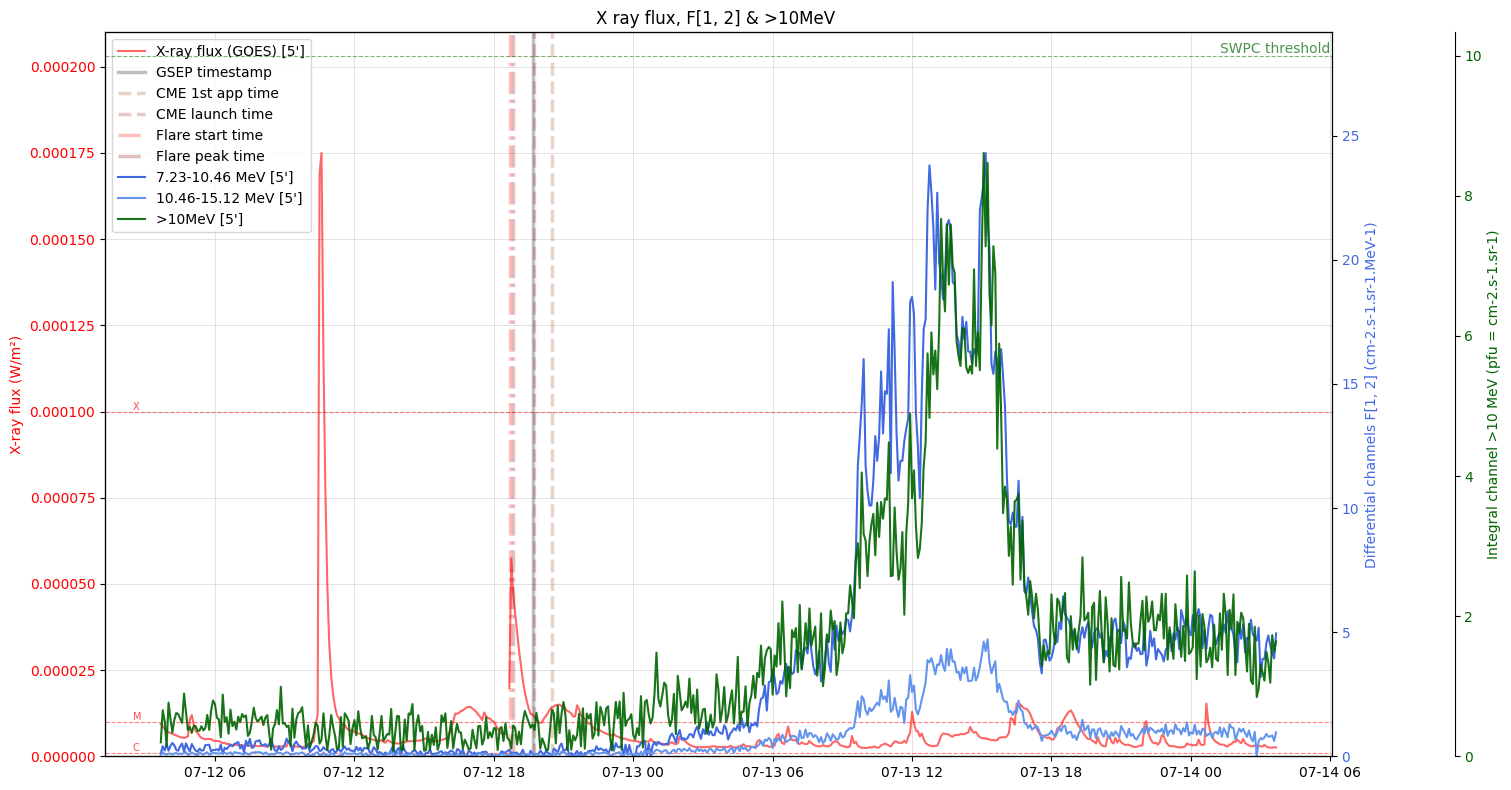

In [63]:
#/!\ interaction not working witg jupyter notebook

sep_dictionary = sep_dictionaries.sep_dictionary

plot_SEP_event(sep_dictionary, index_sep = 200, 
               int_channel = True, channels=[1,2], 
               log_xray = False, log_diff_channels = False, log_int_channel = False, 
               colors_channels=['royalblue', 'cornflowerblue'])

                     time_max_x_ray    time_max_F1    time_max_F2  \
reference_timestamp                                                 
mean_min                 107.517007     779.353741     725.748299   
median_min               -70.000000     705.000000     545.000000   
variance_min2         514135.402106  538876.805517  472735.737583   

                       time_max_F3    time_max_F4    time_max_F5  \
reference_timestamp                                                
mean_min                664.761905     577.823129     480.544218   
median_min              435.000000     385.000000     290.000000   
variance_min2        433290.525114  356202.078092  310319.564812   

                       time_max_F6    time_max_F7    time_max_F8  \
reference_timestamp                                                
mean_min                393.775510     243.401361      -8.707483   
median_min              205.000000     140.000000      75.000000   
variance_min2        291229.654739  34455

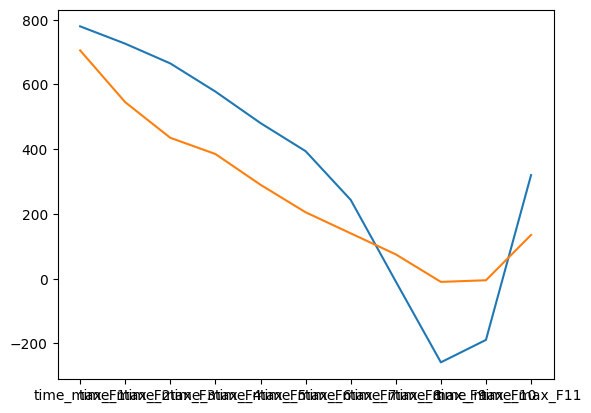

In [64]:
columns = ['time_max_x_ray'] + [f'time_max_F{i}' for i in range(1, 12)]

results = {}

for reference_timestamp, df in best_sep_dictionary.items():
    if df.empty:
        continue
    
    row = {}
    skip_event = False
    
    for col in columns:
        try:
            col_value = df[col].iloc[0]
        except IndexError:
            skip_event = True
            break
        
        mean, _, _ = time_mean(
            pd.Series([reference_timestamp]),
            pd.Series([col_value]),
            diff_max=20
        )
        
        row[col] = mean
    
    if not skip_event:
        results[reference_timestamp] = row

# Création du dataframe final
result_df = pd.DataFrame.from_dict(results, orient='index', columns=columns)
result_df.index.name = 'reference_timestamp'

# --- Calcul des statistiques par colonne ---

stats = {}
for col in columns:
    col_data = result_df[col].dropna()
    col_minutes = col_data.dt.total_seconds() / 60  # Conversion en minutes
    
    stats[col] = {
        'mean_min'     : col_minutes.mean(),
        'median_min'   : col_minutes.median(),
        'variance_min2' : col_minutes.var()
    }

# Création du dataframe des statistiques (3 lignes x 12 colonnes)
stats_df = pd.DataFrame.from_dict(stats, orient='columns').reindex(['mean_min', 'median_min', 'variance_min2'])
stats_df.index.name = 'reference_timestamp'

# Concaténation : stats_df en haut, result_df en dessous
result_df = pd.concat([stats_df, result_df])

del col, col_data, col_minutes, col_value, columns, df, mean, reference_timestamp, results, row, skip_event, stats


print(stats_df.head())

mean_min = stats_df.iloc[0]
median_min = stats_df.iloc[1]


plt.plot(mean_min[1:])
plt.plot(median_min[1:])    

# Flare Time Density

fin étape 1
fin étape 2
fin étape 3
fin étape 4


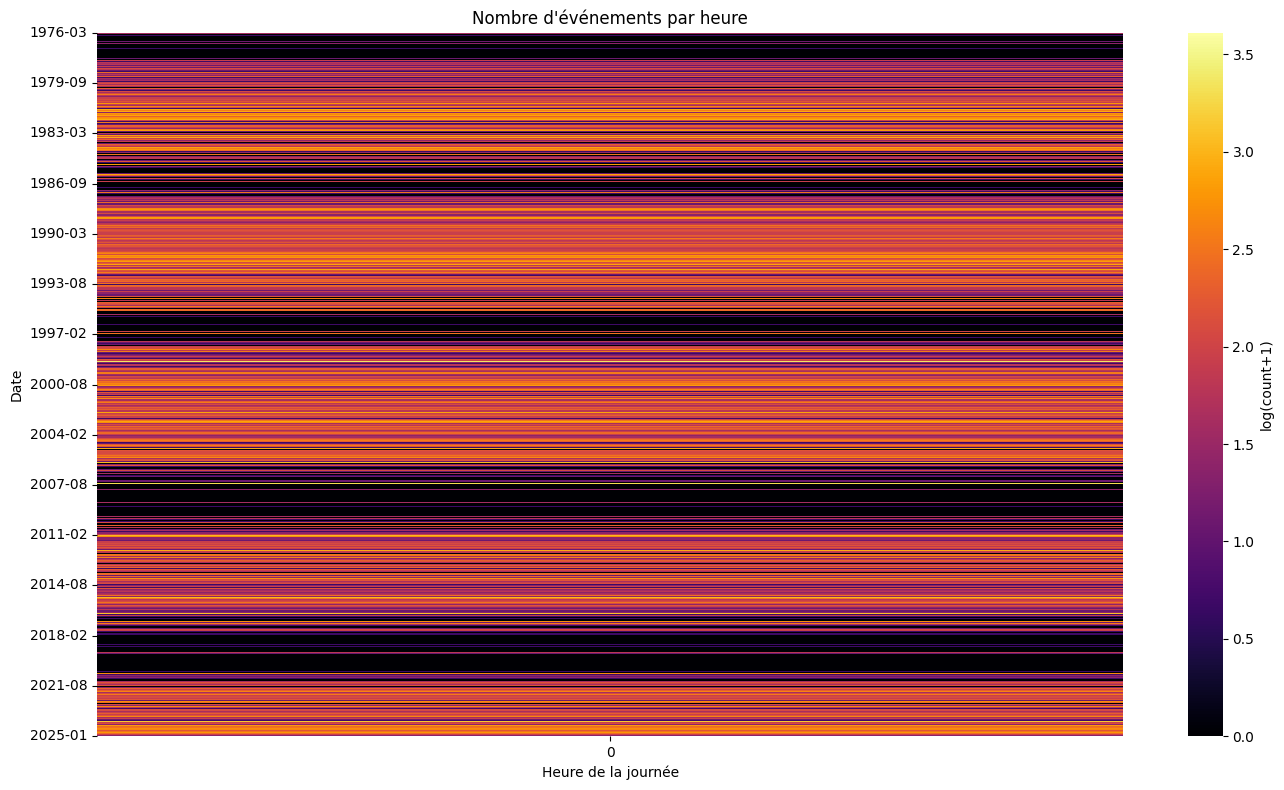

In [65]:
noaa_flares = dataset_reading.noaa_flares

flares_time_peak = noaa_flares['time_peak']

flare_time_density = compute_event_counts(flares_time_peak, window_hours=24, step_hours=24)

plot_heatmap(flare_time_density , log_scale=True)

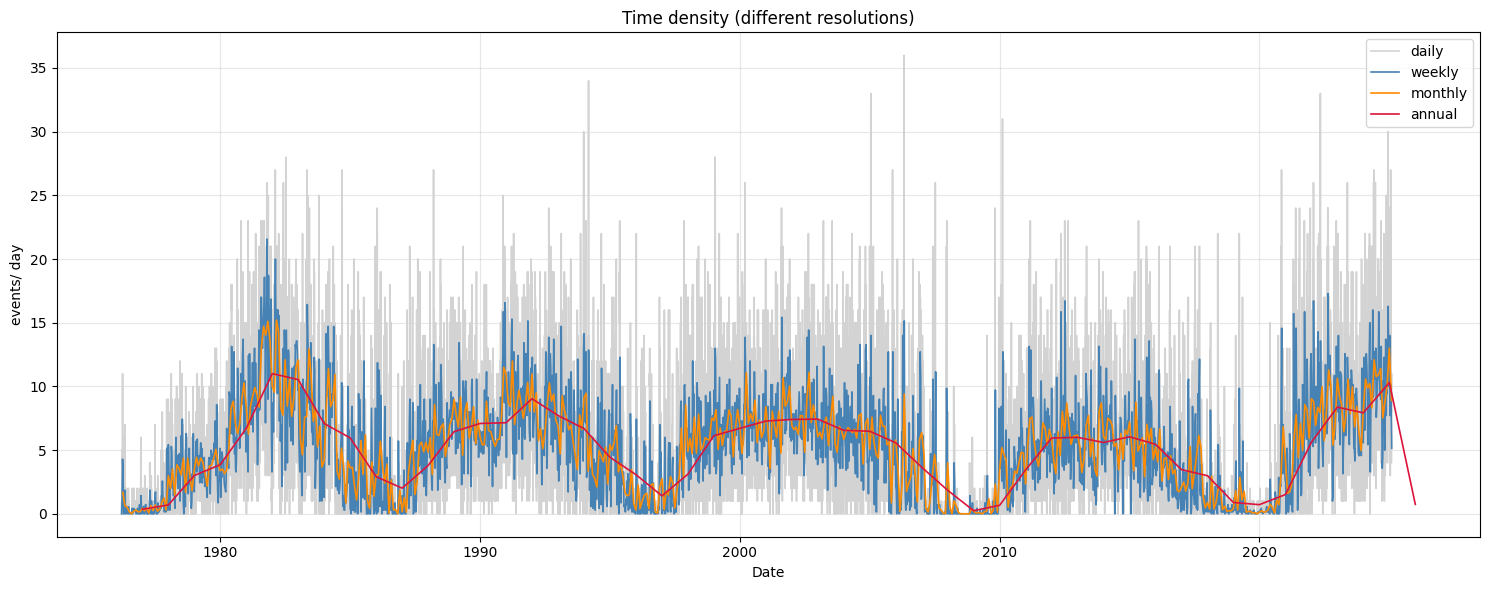

In [66]:
plot_timeseries_overlay(flare_time_density, normalize=True)

fin étape 1
fin étape 2
fin étape 3
fin étape 4


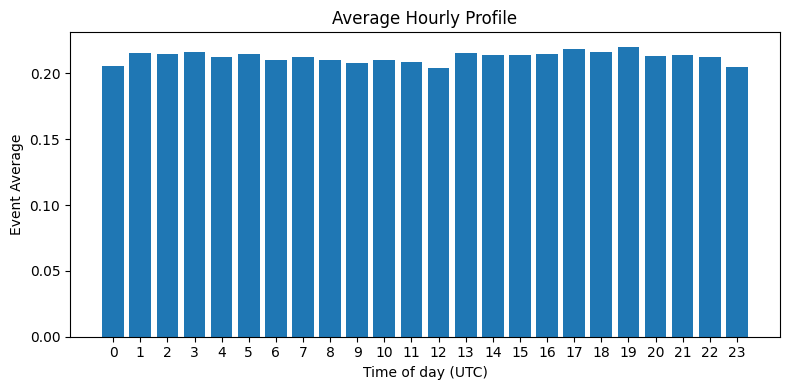

In [67]:
flare_time_density_hour = compute_event_counts(flares_time_peak, window_hours=1, step_hours=1)
profil = flare_time_density_hour['count_events'].groupby(level='hour').mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(profil.index, profil.values)
ax.set_xlabel("Time of day (UTC)")
ax.set_ylabel("Event Average")
ax.set_title("Average Hourly Profile")
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

# Days with SEP (class imbalance)

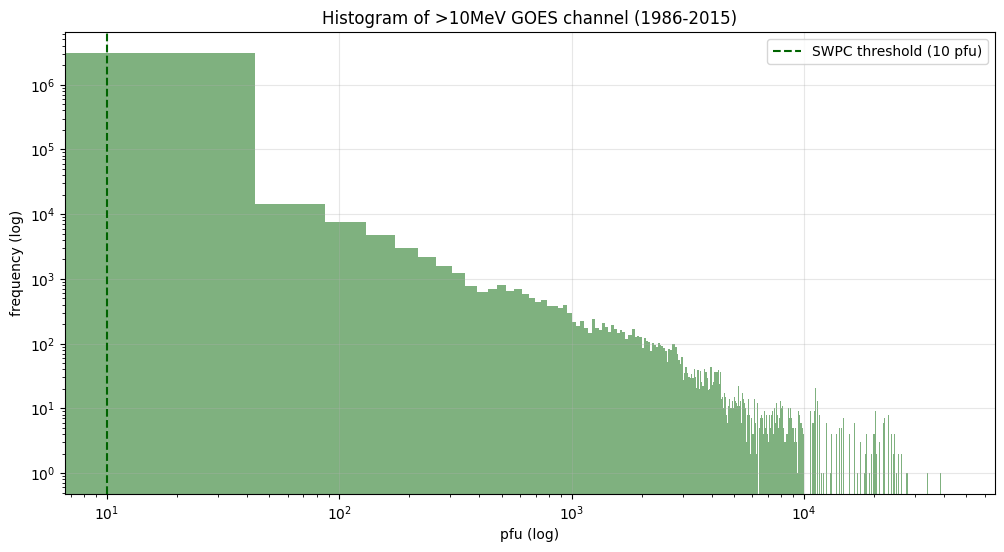

In [68]:
formal_sep = dataset_reading.formal_sep

int_channel = formal_sep['ZPGT10W_CORR']

plt.figure(figsize=(12, 6))
plt.hist(int_channel.dropna(), bins=1000, range=(0, 43500), color='darkgreen', alpha = 0.5)
plt.axvline(x = 10, label = 'SWPC threshold (10 pfu)', linestyle = '--', color = 'darkgreen')
plt.title("Histogram of >10MeV GOES channel (1986-2015)")
plt.xlabel("pfu (log)")
plt.ylabel("frequency (log)")
plt.yscale('log')
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


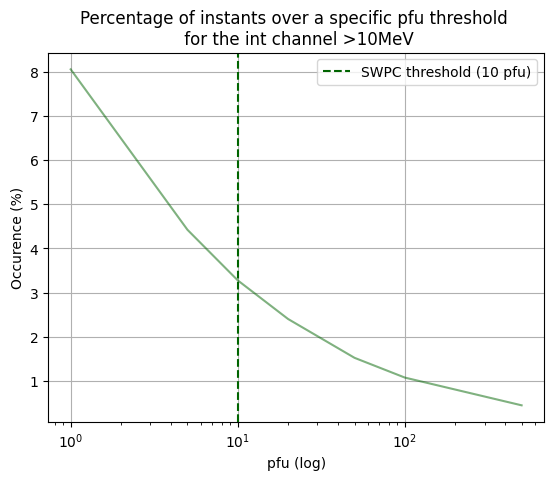

In [69]:
count_liste = []
percentage_liste = []

liste = [1,5,10,20,50,100,500]
for i in liste: 
    count = (int_channel > i).sum()
    percentage = count/len(int_channel) * 100
    count_liste.append(count)
    percentage_liste.append(percentage)
    
plt.plot(liste, percentage_liste, color = 'darkgreen', alpha = 0.5)
plt.axvline(x = 10, label = 'SWPC threshold (10 pfu)', linestyle = '--', color = 'darkgreen')
plt.ylabel('Occurence (%)')
plt.xlabel('pfu (log)')
plt.xscale('log')
plt.title('Percentage of instants over a specific pfu threshold \n for the int channel >10MeV')
plt.grid()
plt.legend()
plt.show()

# Correlation

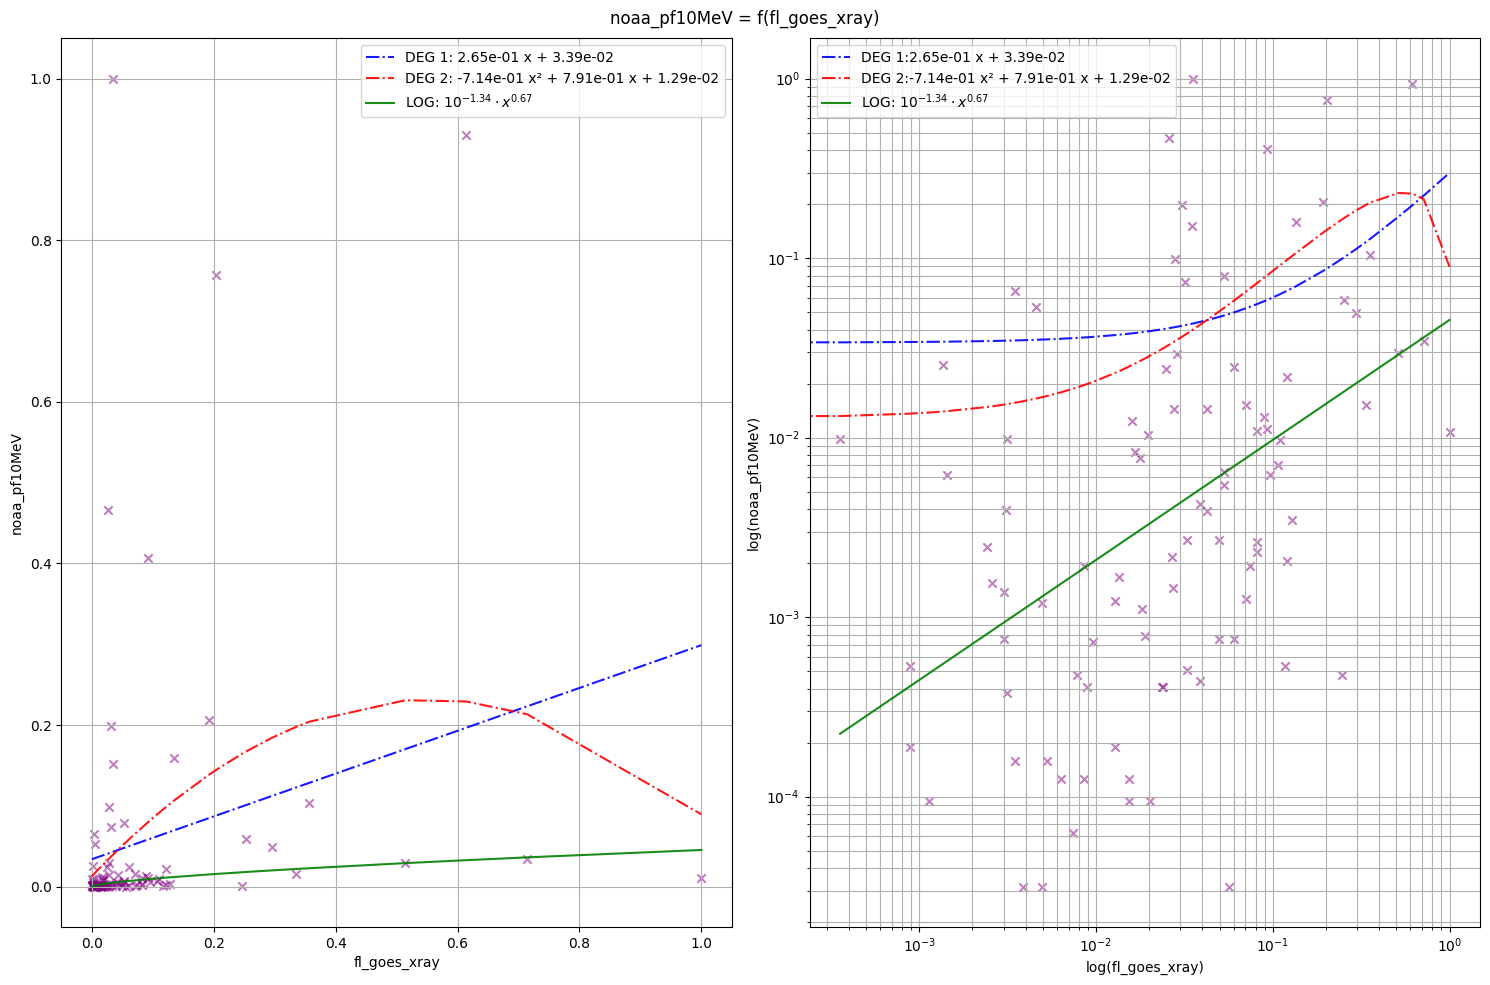

(np.float64(0.2649260562003962),
 np.float64(0.03387992170855164),
 np.float64(-0.7140398540994134),
 np.float64(0.790589746163404),
 np.float64(0.012909537966299265))

In [70]:
GSEP_list = dataset_reading.GSEP_list.dropna(subset=['cdaw_evn_max', 'lasco_cme_width', 'lasco_linear_speed', 'fl_rise_time', 
                                                     'fl_lon', 'fl_lat','fl_goes_class', 'noaa_pf10MeV', 'fluence_gt10MeV'])

GSEP_list['fl_goes_xray'] = GSEP_list['fl_goes_class'].apply(convert_prefix_value)

scatter_parameters(GSEP_list['fl_goes_xray'], GSEP_list['noaa_pf10MeV'], 
                   name_p1= 'fl_goes_xray', name_p2='noaa_pf10MeV')

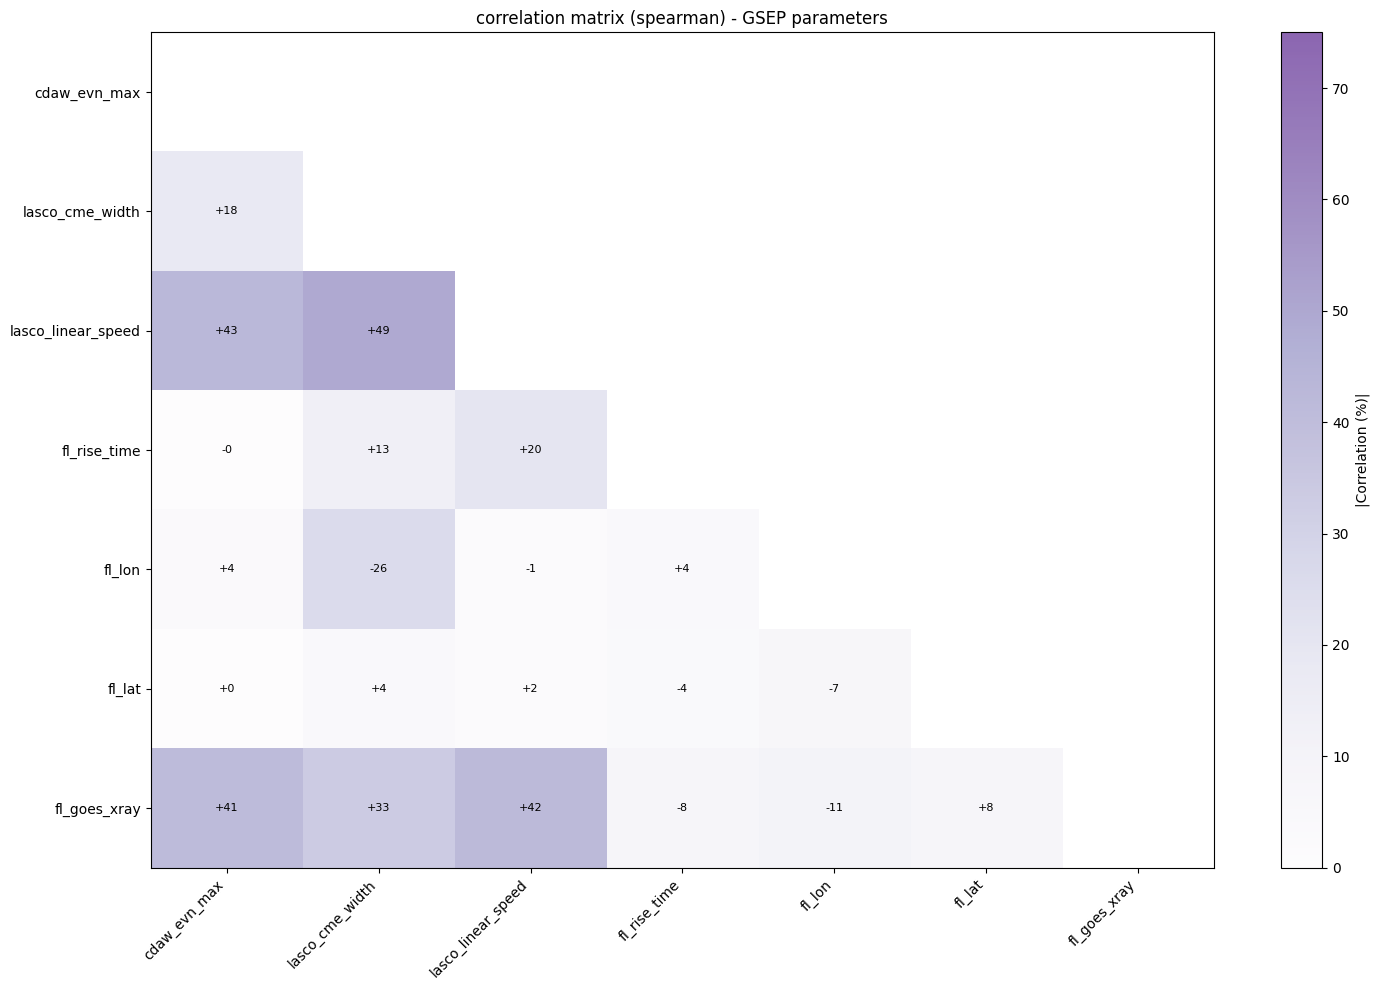

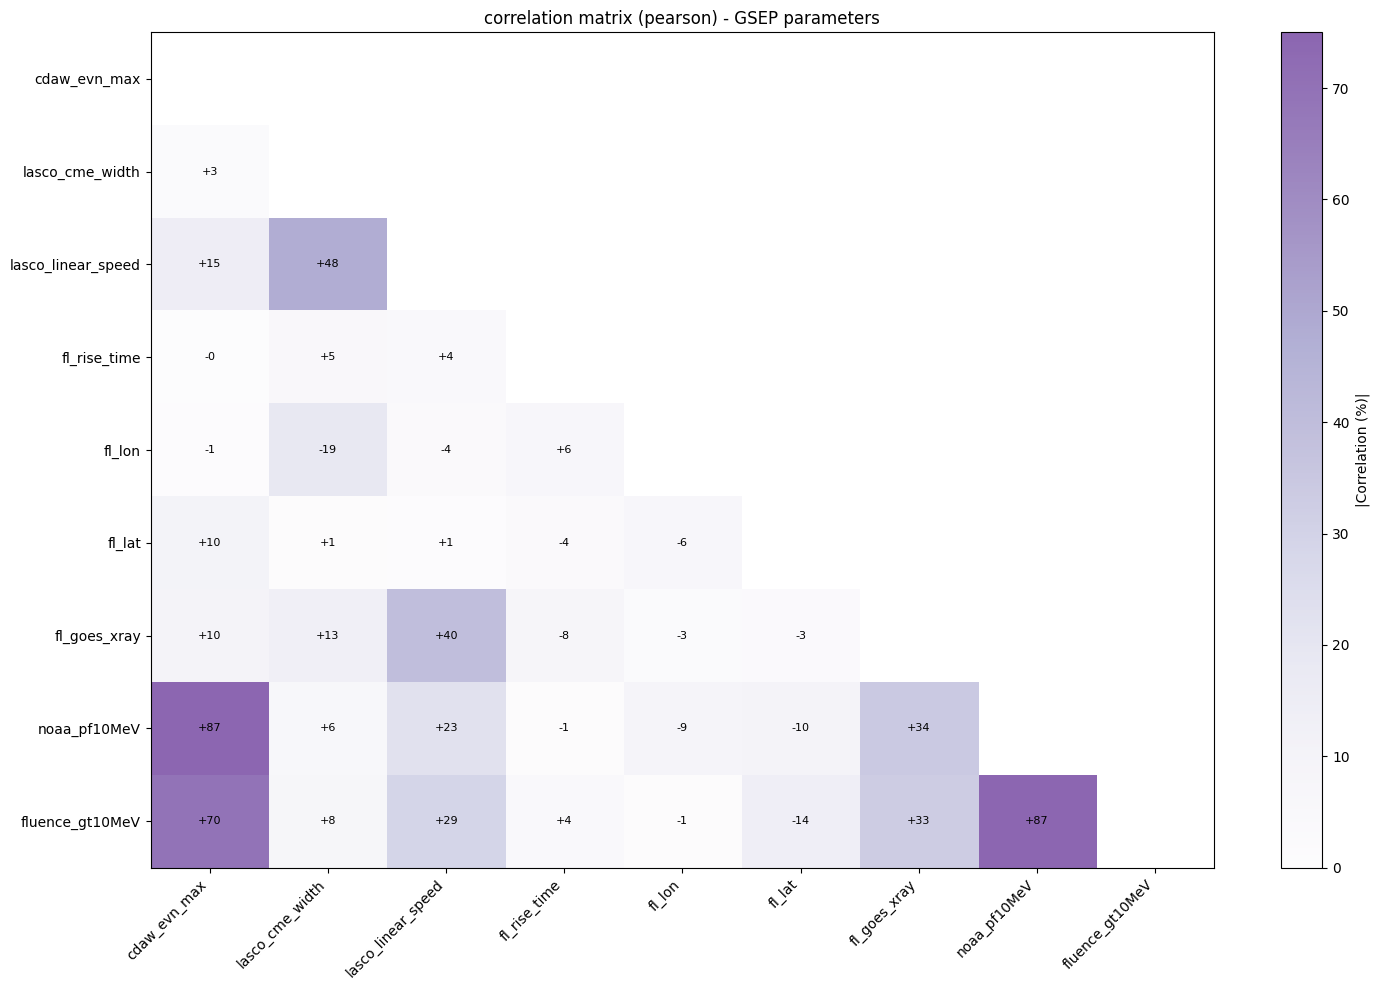

                    cdaw_evn_max  fl_goes_xray     fl_lat        fl_lon  \
cdaw_evn_max            0.000000  3.133417e+01  10.110894  4.867825e+00   
fl_goes_xray           31.334174  1.421085e-14  11.144810  7.934683e+00   
fl_lat                 10.110894  1.114481e+01   0.000000  9.480706e-01   
fl_lon                  4.867825  7.934683e+00   0.948071  1.421085e-14   
fl_rise_time            0.298150  7.450304e-02   0.181583  1.993024e+00   
fluence_gt10MeV              NaN           NaN        NaN           NaN   
lasco_cme_width        15.160402  2.026460e+01   2.724327  6.753989e+00   
lasco_linear_speed     28.037298  2.187354e+00   0.582038  2.284862e+00   
noaa_pf10MeV                 NaN           NaN        NaN           NaN   

                    fl_rise_time  fluence_gt10MeV  lasco_cme_width  \
cdaw_evn_max            0.298150              NaN        15.160402   
fl_goes_xray            0.074503              NaN        20.264597   
fl_lat                  0.181583       

In [71]:
GSEP = gsep_extended.GSEP_extended

corr_matrix_spearman = correlation_matrix(GSEP, 
                                        ['cdaw_evn_max', 'lasco_cme_width', 'lasco_linear_speed',
                                        'fl_rise_time', 'fl_lon', 'fl_lat', 'fl_goes_xray'], 
                                          method='spearman', plot = True)

corr_matrix_pearson = correlation_matrix(GSEP, 
                                        ['cdaw_evn_max', 'lasco_cme_width', 'lasco_linear_speed',
                                        'fl_rise_time', 'fl_lon', 'fl_lat', 'fl_goes_xray', 
                                        'noaa_pf10MeV', 'fluence_gt10MeV'], 
                                        method='pearson', plot = True)

diff_pearson_spearman = abs(corr_matrix_spearman - corr_matrix_pearson)
print(diff_pearson_spearman)